# Chạy kết quả XAI cho các checkpoint của thực nghiệm chính

File phương pháp RDX thực hiện theo: application\XAI_analysis\RDX_2013_2017.ipynb
File phương pháp SHAP thực hiện theo: application\XAI_analysis\SHAP_2013_2017.ipynb

## Thư viện sử dụng

In [1]:
from dataclasses import dataclass
from pathlib import Path
import importlib.util
import warnings

import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import argrelextrema
from IPython.display import display

%matplotlib inline
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PERIODS = ('good', 'bad')
FEATURE_COLUMNS = ('close', 'balance', 'position', 'MACD', 'RSI', 'CCI', 'ADX')
MARKET_COLUMNS = ('close', 'MACD', 'RSI', 'CCI', 'ADX')
ACTION_VALUES = np.arange(-5, 6, dtype=np.int64)


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        data_dir = candidate / 'data' / 'data_storer' / 'data_research'
        result_dir = candidate / 'application' / 'JOURNAL_2026' / 'V-Experiment Results'
        if data_dir.is_dir() and result_dir.is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục gốc của dự án SARSA_FinancialRL.')


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / 'data' / 'data_storer' / 'data_research'
EXPERIMENT_ROOT = PROJECT_ROOT / 'application' / 'JOURNAL_2026' / 'V-Experiment Results'
TICKERS = tuple(sorted(
    path.name for path in EXPERIMENT_ROOT.iterdir()
    if path.is_dir() and (path / 'xai_model_checkpoint.pt').is_file()
))
if not TICKERS:
    raise FileNotFoundError(f'Không tìm thấy checkpoint XAI trong {EXPERIMENT_ROOT}')

SHAP_AVAILABLE = importlib.util.find_spec('shap') is not None
print('Project root :', PROJECT_ROOT)
print('Device       :', DEVICE)
print('Tickers      :', ', '.join(TICKERS))
print('SHAP sẵn có :', SHAP_AVAILABLE)

Project root : D:\NCKH\SARSA_FinancialRL
Device       : cpu
Tickers      : ACB, FPT, GAS, HPG, SSI, VCB
SHAP sẵn có : True


## Truyền dữ liệu test cho RDX và SHAP từ checkpoint của thực nghiệm chính trong phần V.

In [2]:
def load_test_frame(ticker: str, period: str) -> pd.DataFrame:
    """Nạp và kiểm tra dữ liệu test gốc dùng để replay cho RDX/SHAP."""
    csv_path = DATA_ROOT / 'test' / f'{period}_test_{ticker}.csv'
    if not csv_path.is_file():
        raise FileNotFoundError(f'Thiếu dữ liệu test: {csv_path}')

    frame = pd.read_csv(csv_path)
    required = {'time', *MARKET_COLUMNS}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f'{csv_path.name} thiếu cột: {sorted(missing)}')

    frame = frame.copy()
    frame['time'] = pd.to_datetime(frame['time'], errors='raise')
    frame[list(MARKET_COLUMNS)] = frame[list(MARKET_COLUMNS)].apply(
        pd.to_numeric, errors='coerce'
    )
    if frame[list(MARKET_COLUMNS)].isna().any().any():
        raise ValueError(f'{csv_path.name} chứa NaN hoặc giá trị không phải số.')

    frame = (
        frame.sort_values('time')
        .drop_duplicates('time', keep='last')
        .reset_index(drop=True)
    )
    if len(frame) < 2 or not frame['time'].is_monotonic_increasing:
        raise ValueError(f'Dữ liệu test không hợp lệ: {csv_path.name}')
    return frame


test_data = {
    ticker: {period: load_test_frame(ticker, period) for period in PERIODS}
    for ticker in TICKERS
}
test_inventory = pd.DataFrame([
    {
        'ticker': ticker,
        'period': period.upper(),
        'rows': len(frame),
        'start_date': frame['time'].iloc[0].date(),
        'end_date': frame['time'].iloc[-1].date(),
    }
    for ticker, periods in test_data.items()
    for period, frame in periods.items()
])
display(test_inventory)
print(f'Đã nạp {len(test_inventory)} tập dữ liệu test.')

,ticker,period,rows,start_date,end_date
0,ACB,GOOD,747,2019-01-02,2021-12-31
1,ACB,BAD,498,2022-01-04,2023-12-29
2,FPT,GOOD,752,2019-01-02,2021-12-31
3,FPT,BAD,498,2022-01-04,2023-12-29
4,GAS,GOOD,752,2019-01-02,2021-12-31
5,GAS,BAD,498,2022-01-04,2023-12-29
6,HPG,GOOD,752,2019-01-02,2021-12-31
7,HPG,BAD,498,2022-01-04,2023-12-29
8,SSI,GOOD,752,2019-01-02,2021-12-31
9,SSI,BAD,498,2022-01-04,2023-12-29


Đã nạp 12 tập dữ liệu test.


## Truyền checkpoint từ thực nghiệm gốc trong phần V

In [3]:
class QNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 32),
            nn.ReLU(),
            nn.Linear(32, 11),
        )

    def forward(self, states: torch.Tensor) -> torch.Tensor:
        return self.net(states)


class EpistemicVAE(nn.Module):
    def __init__(self, latent_dim: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(18, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU()
        )
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(), nn.Linear(64, 18),
        )

    def encode(self, values: torch.Tensor):
        hidden = self.encoder(values)
        return self.fc_mu(hidden), self.fc_logvar(hidden)

    def forward(self, states: torch.Tensor, actions_onehot: torch.Tensor):
        values = torch.cat([states, actions_onehot], dim=-1)
        mu, logvar = self.encode(values)
        std = torch.exp(0.5 * logvar)
        reconstruction = self.decoder(mu + torch.randn_like(std) * std)
        return reconstruction, mu, logvar


class CostNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(18, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid()
        )

    def forward(self, states: torch.Tensor, actions_onehot: torch.Tensor):
        values = torch.cat([states, actions_onehot], dim=-1)
        return self.net(values).squeeze(-1)


@dataclass(frozen=True)
class FrozenScaler:
    mean: np.ndarray
    std: np.ndarray

    def transform(self, states) -> np.ndarray:
        values = np.asarray(states, dtype=np.float32)
        return (values - self.mean) / self.std


@dataclass
class XAIAgent:
    ticker: str
    period: str
    seed: int
    model_key: str
    q_network: QNetwork
    vae: EpistemicVAE
    cost_network: CostNetwork
    scaler: FrozenScaler
    test_frame: pd.DataFrame
    checkpoint: dict

    def q_values(self, raw_states) -> np.ndarray:
        values = np.asarray(raw_states, dtype=np.float32).reshape(-1, 7)
        scaled = self.scaler.transform(values)
        tensor = torch.as_tensor(scaled, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            return self.q_network(tensor).cpu().numpy()


def load_xai_agent(ticker: str) -> XAIAgent:
    checkpoint_path = EXPERIMENT_ROOT / ticker / 'xai_model_checkpoint.pt'
    # Đây là checkpoint do chính pipeline thực nghiệm của dự án tạo ra.
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    required_keys = {
        'ticker', 'period', 'model_key', 'seed', 'scaler_mean', 'scaler_std',
        'q_network_state_dict', 'vae_state_dict', 'cost_network_state_dict',
    }
    missing = required_keys - set(checkpoint)
    if missing:
        raise KeyError(f'Checkpoint {ticker} thiếu khóa: {sorted(missing)}')
    if str(checkpoint['ticker']).upper() != ticker.upper():
        raise ValueError(f'Checkpoint {ticker} chứa ticker không khớp.')

    period = str(checkpoint['period']).lower()
    if period not in test_data[ticker]:
        raise ValueError(f'Period không được hỗ trợ trong checkpoint {ticker}: {period}')

    mean = np.asarray(checkpoint['scaler_mean'], dtype=np.float32)
    std = np.asarray(checkpoint['scaler_std'], dtype=np.float32)
    if mean.shape != (7,) or std.shape != (7,):
        raise ValueError(f'Scaler {ticker} phải có shape (7,), nhận {mean.shape}/{std.shape}.')
    if not np.isfinite(mean).all() or not np.isfinite(std).all() or np.any(std <= 0):
        raise ValueError(f'Scaler của {ticker} chứa giá trị không hợp lệ.')

    q_network = QNetwork().to(DEVICE)
    q_network.load_state_dict(checkpoint['q_network_state_dict'])

    vae_state = checkpoint['vae_state_dict']
    if vae_state is None:
        raise ValueError(f'Checkpoint {ticker} không chứa VAE state dict.')
    latent_dim = int(vae_state['fc_mu.weight'].shape[0])
    vae = EpistemicVAE(latent_dim=latent_dim).to(DEVICE)
    vae.load_state_dict(vae_state)

    cost_state = checkpoint['cost_network_state_dict']
    if cost_state is None:
        raise ValueError(f'Checkpoint {ticker} không chứa cost-network state dict.')
    cost_network = CostNetwork().to(DEVICE)
    cost_network.load_state_dict(cost_state)

    q_network.eval()
    vae.eval()
    cost_network.eval()
    return XAIAgent(
        ticker=ticker,
        period=period,
        seed=int(checkpoint['seed']),
        model_key=str(checkpoint['model_key']),
        q_network=q_network,
        vae=vae,
        cost_network=cost_network,
        scaler=FrozenScaler(mean=mean, std=std),
        test_frame=test_data[ticker][period],
        checkpoint=checkpoint,
    )


xai_agents = {ticker: load_xai_agent(ticker) for ticker in TICKERS}
checkpoint_inventory_rows = []
for ticker, agent in xai_agents.items():
    first = agent.test_frame.iloc[0]
    initial_state = np.asarray(
        [first['close'], 1000.0, 0.0, first['MACD'], first['RSI'], first['CCI'], first['ADX']],
        dtype=np.float32,
    )
    q_values = agent.q_values(initial_state)
    if q_values.shape != (1, 11) or not np.isfinite(q_values).all():
        raise ValueError(f'Q-network smoke test thất bại: {ticker}, shape={q_values.shape}')

    # Alias tương thích với tên biến trong hai notebook RDX/SHAP tham chiếu.
    globals()[f'df_processed_test_{ticker}'] = agent.test_frame
    globals()[f'qsa_{ticker}'] = agent.q_network
    checkpoint_inventory_rows.append({
        'ticker': ticker,
        'period': agent.period.upper(),
        'seed': agent.seed,
        'model_key': agent.model_key,
        'test_rows': len(agent.test_frame),
        'q_output_shape': q_values.shape,
    })

checkpoint_inventory = pd.DataFrame(checkpoint_inventory_rows)
display(checkpoint_inventory)
print('Đã nạp và kiểm tra thành công toàn bộ checkpoint XAI.')

,ticker,period,seed,model_key,test_rows,q_output_shape
0,ACB,BAD,48,UNCERTAINTY_AWARE_UCB_009,498,"(1, 11)"
1,FPT,BAD,46,UNCERTAINTY_AWARE_UCB_009,498,"(1, 11)"
2,GAS,BAD,50,UNCERTAINTY_AWARE_UCB_009,498,"(1, 11)"
3,HPG,BAD,47,UNCERTAINTY_AWARE_UCB_009,498,"(1, 11)"
4,SSI,BAD,55,UNCERTAINTY_AWARE_UCB_009,498,"(1, 11)"
5,VCB,BAD,42,UNCERTAINTY_AWARE_UCB_009,498,"(1, 11)"


Đã nạp và kiểm tra thành công toàn bộ checkpoint XAI.


## Vẽ biểu đồ giá cho các bộ test để kiểm tra

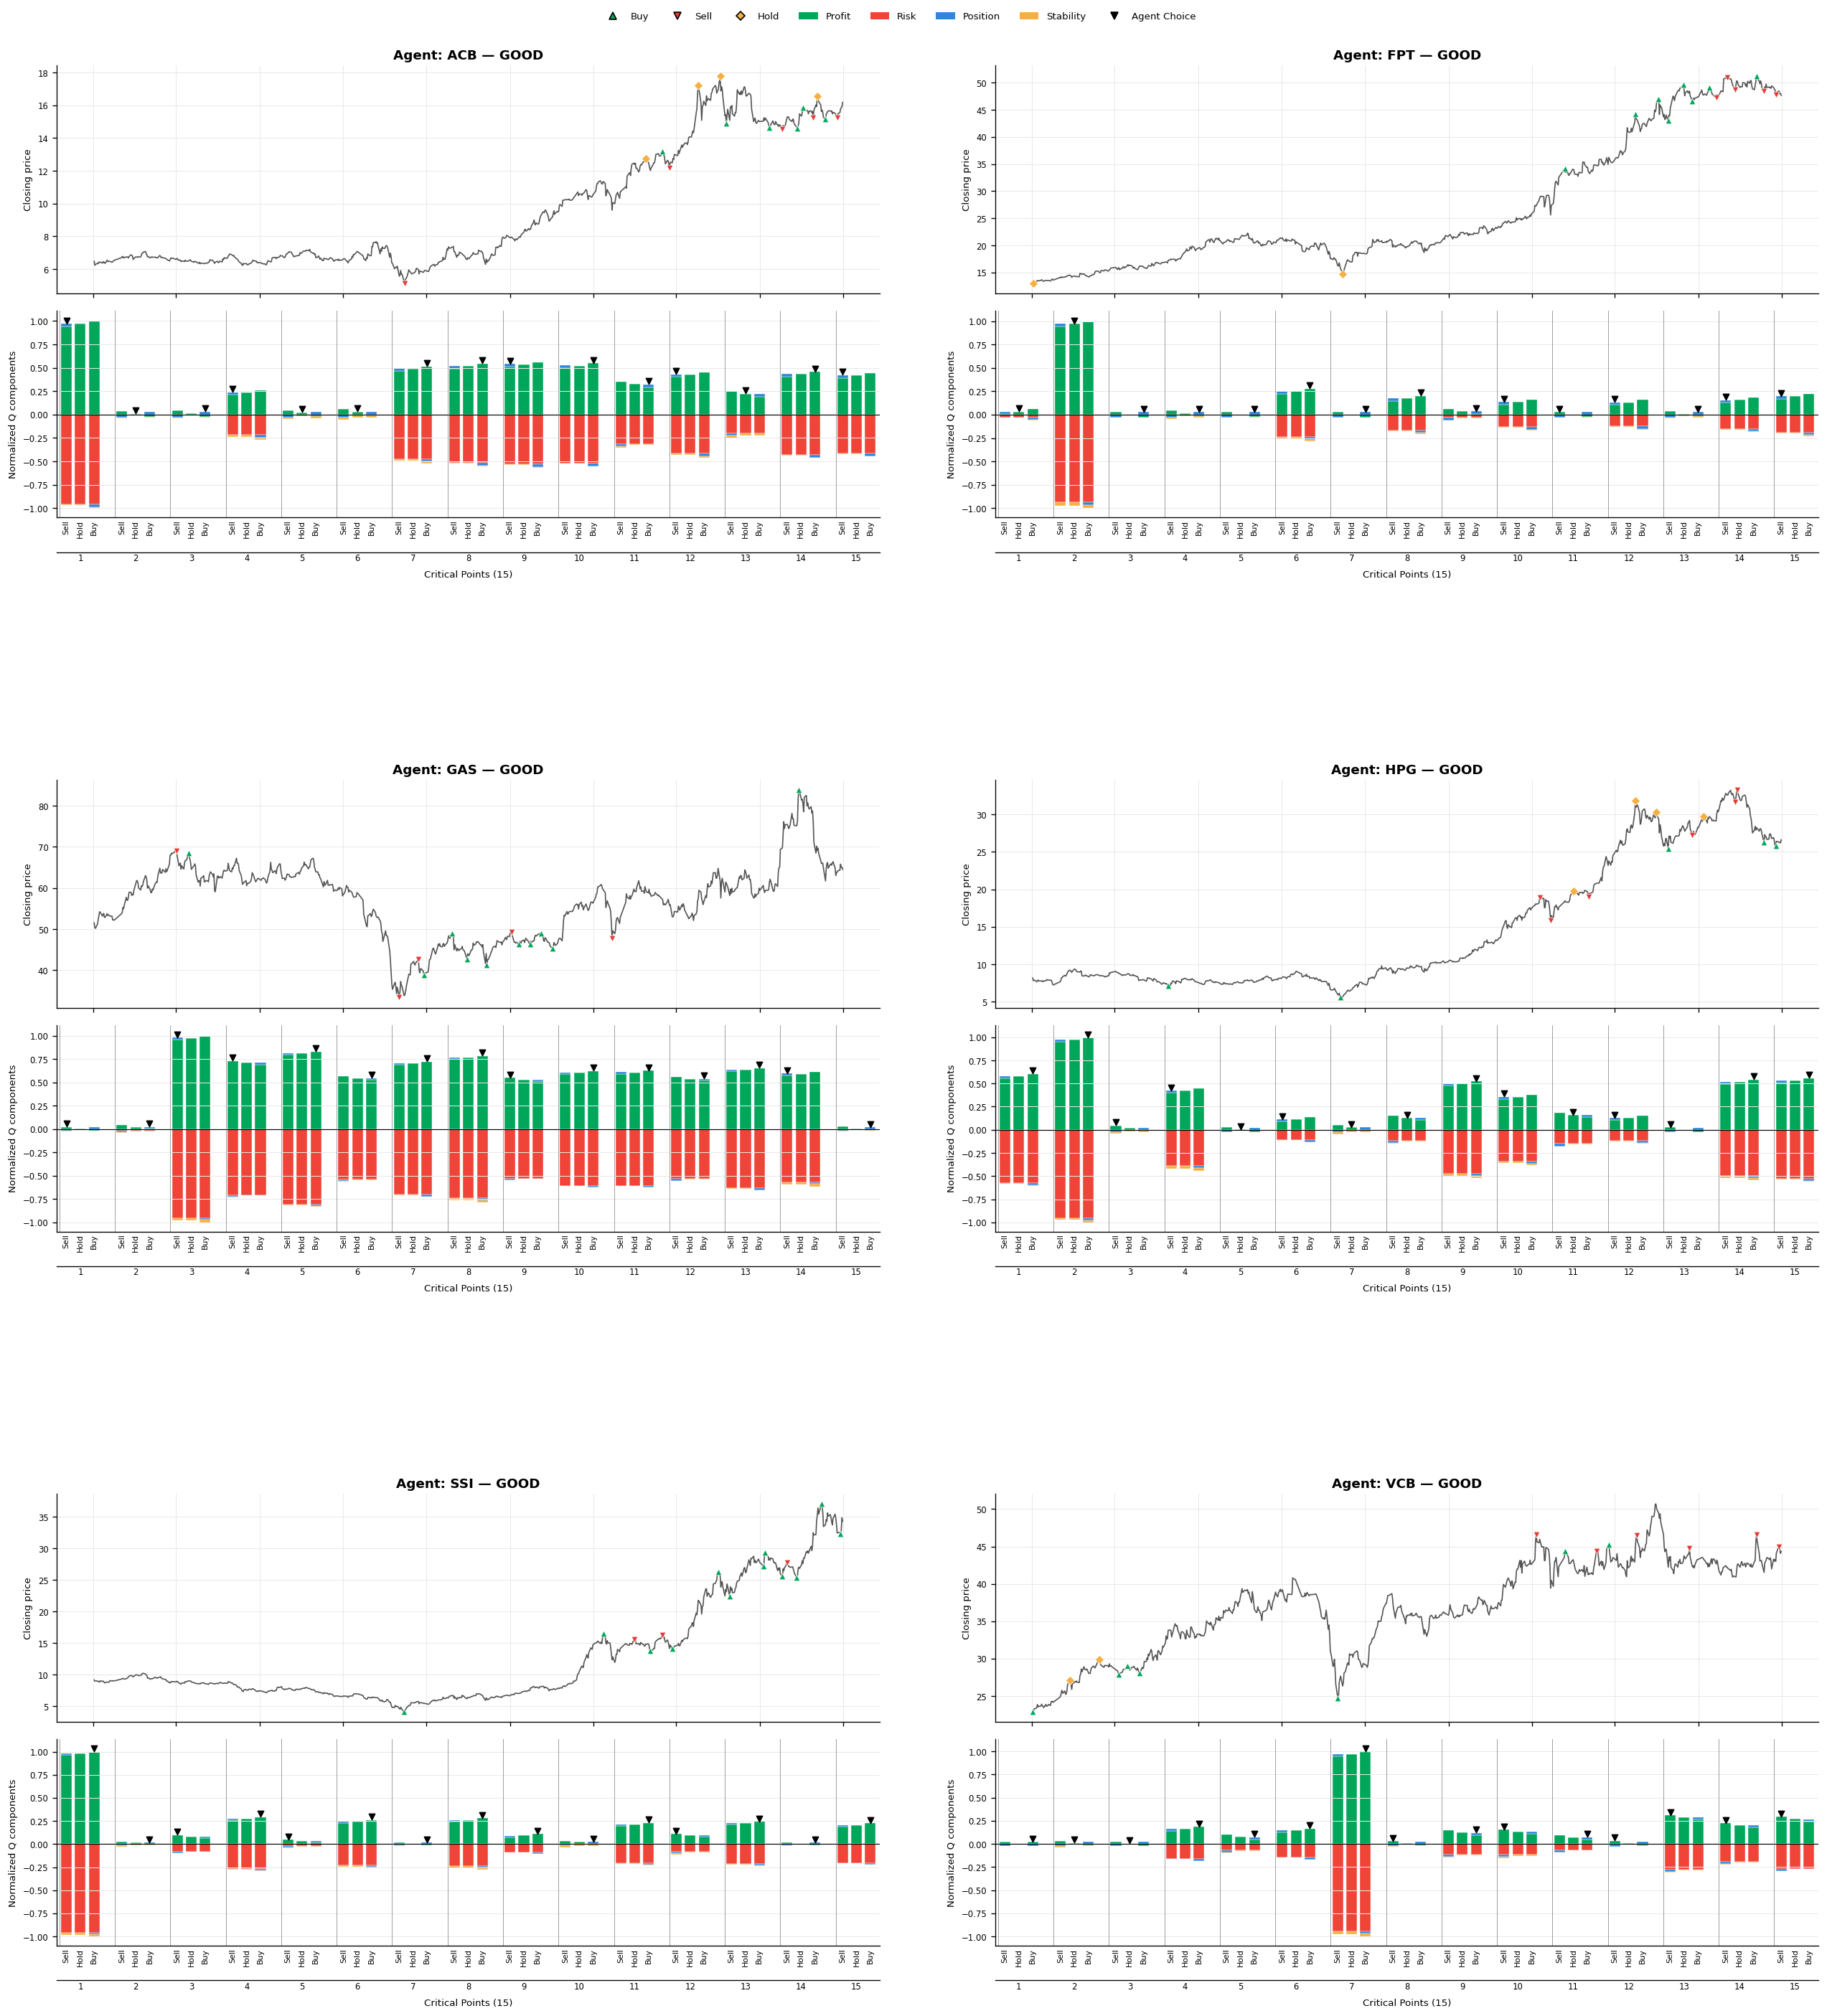

In [4]:
# Dùng cùng checkpoint UCB-VAE và scaler, chỉ thay trajectory bằng GOOD test.
GOOD_INITIAL_BALANCE, GOOD_TRANSACTION_FEE, GOOD_TOP_K = 1000.0, 0.001, 15
GOOD_COMPONENTS = ('Profit', 'Risk', 'Position', 'Stability')


def replay_good_test(agent, frame):
    cash, position = GOOD_INITIAL_BALANCE, 0
    states, action_indices = [], []
    for step in range(len(frame) - 1):
        row = frame.iloc[step]; price = float(row['close'])
        state = np.asarray([
            price, cash, position, row['MACD'], row['RSI'], row['CCI'], row['ADX']
        ], dtype=np.float32)
        max_buy = int(cash // (price * (1.0 + GOOD_TRANSACTION_FEE)))
        valid = np.asarray([
            -position <= int(action) <= max_buy for action in ACTION_VALUES
        ], dtype=bool)
        action_index = int(np.argmax(np.where(valid, agent.q_values(state)[0], -np.inf)))
        requested = int(ACTION_VALUES[action_index])
        executed = min(requested, max_buy) if requested > 0 else -min(-requested, position)
        cash -= executed * price + abs(executed) * price * GOOD_TRANSACTION_FEE
        position += executed
        states.append(state); action_indices.append(action_index)
    return np.asarray(states, np.float32), np.asarray(action_indices, np.int64)


def decompose_good_q(agent, frame, states):
    prices = frame['close'].to_numpy(float)[:len(states)]
    returns = pd.Series(prices).pct_change().fillna(0.0).to_numpy()
    running_max = np.maximum.accumulate(prices)
    ma10 = pd.Series(prices).rolling(10, min_periods=1).mean().to_numpy()
    result = np.zeros((len(states), len(ACTION_VALUES), len(GOOD_COMPONENTS)))
    for step, state in enumerate(states):
        q_values = agent.q_values(state)[0]
        portfolio = max(float(state[1] + state[2] * prices[step]), 10.0)
        drawdown = (prices[step] - running_max[step]) / max(running_max[step], 1e-9)
        trend = np.sign(prices[step] - ma10[step])
        for action_index, action in enumerate(ACTION_VALUES):
            risk = -0.5 * abs(drawdown)
            stability = -0.1 * abs(returns[step])
            position_score = (0.0 if action == 0 else
                              0.005 if np.sign(action) == trend else -0.005)
            profit = float(q_values[action_index]) / portfolio - risk - position_score - stability
            result[step, action_index] = (profit, risk, position_score, stability)
    return result


def good_critical_points(frame, action_indices, top_k=15):
    prices = frame['close'].to_numpy(float)[:len(action_indices)]
    actions = ACTION_VALUES[action_indices]
    running_max = np.maximum.accumulate(prices)
    drawdown = (prices - running_max) / np.maximum(running_max, 1e-9)
    reversals = np.concatenate([
        argrelextrema(prices, np.greater, order=10)[0],
        argrelextrema(prices, np.less, order=10)[0],
    ]).astype(int)
    median = float(np.median(prices))
    changes = np.abs(np.diff(actions))
    shifts = (np.where(changes >= 3)[0] + 1).astype(int)
    priority = [int(np.argmin(prices)), int(np.argmin(drawdown))]
    priority += sorted(reversals, key=lambda i: abs(prices[i] - median), reverse=True)
    priority += sorted(shifts, key=lambda i: changes[i - 1], reverse=True)
    priority += list(np.argsort(drawdown))
    selected = []
    for index in priority:
        if int(index) not in selected: selected.append(int(index))
        if len(selected) == min(top_k, len(prices)): break
    return sorted(selected)


good_msx_plot_data = {}
for ticker, agent in xai_agents.items():
    frame = test_data[ticker]['good']
    states, actions = replay_good_test(agent, frame)
    decomposed = decompose_good_q(agent, frame, states)
    points = good_critical_points(frame, actions, GOOD_TOP_K)
    good_msx_plot_data[ticker] = {
        'frame': frame, 'states': states, 'actions': actions,
        'decomposed': decomposed, 'critical_points': points,
    }

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
good_component_colors = {
    'Profit': '#00A65A', 'Risk': '#F04438',
    'Position': '#2E86DE', 'Stability': '#F5B041',
}
good_comparisons = (('Sell', 0), ('Hold', 5), ('Buy', 10))
good_offsets = {'Sell': 0, 'Hold': 1, 'Buy': 2}
fig_msx_good = plt.figure(figsize=(22, 24), dpi=120)
outer = fig_msx_good.add_gridspec(
    3, 2, left=0.055, right=0.985, top=0.955, bottom=0.045,
    wspace=0.14, hspace=0.58,
)

for agent_index, ticker in enumerate(TICKERS):
    item = good_msx_plot_data[ticker]
    frame, actions = item['frame'], item['actions']
    decomposed, points = item['decomposed'], item['critical_points']
    inner = outer[agent_index // 2, agent_index % 2].subgridspec(
        2, 1, height_ratios=(1.05, 0.95), hspace=0.08
    )
    ax_price = fig_msx_good.add_subplot(inner[0]); ax_bar = fig_msx_good.add_subplot(inner[1])
    scale = max(float(np.max(np.abs(decomposed[points]))), 1e-12)
    times = pd.to_datetime(frame.iloc[points]['time']).to_numpy()
    prices = frame.iloc[points]['close'].to_numpy(float)
    point_actions = ACTION_VALUES[actions[points]]
    ax_price.plot(frame['time'], frame['close'], color='#555555', linewidth=1.0)
    for mask, marker, color in ((point_actions > 0, '^', '#00A65A'),
                                 (point_actions < 0, 'v', '#E53935'),
                                 (point_actions == 0, 'D', '#F5B041')):
        ax_price.scatter(times[mask], prices[mask], s=27, marker=marker, color=color,
                         edgecolor='white', linewidth=0.45, zorder=4)
    ax_price.set_title(f'Agent: {ticker} — GOOD', fontsize=11, fontweight='bold', pad=5)
    ax_price.set_ylabel('Closing price', fontsize=8); ax_price.tick_params(labelsize=7)
    ax_price.tick_params(axis='x', labelbottom=False); ax_price.grid(color='#E8E8E8', linewidth=0.6)
    ax_price.spines[['top', 'right']].set_visible(False)

    positions, labels, centers, choice_x, choice_y = [], [], [], [], []
    values = {name: [] for name in GOOD_COMPONENTS}
    for point_index, step in enumerate(points):
        start = point_index * 4; centers.append(start + 1)
        chosen = int(ACTION_VALUES[actions[step]])
        selected_label = 'Buy' if chosen > 0 else 'Sell' if chosen < 0 else 'Hold'
        selected_vector = None
        for offset, (label, action_index) in enumerate(good_comparisons):
            vector = decomposed[step, action_index] / scale
            positions.append(start + offset); labels.append(label)
            for component_index, component in enumerate(GOOD_COMPONENTS):
                values[component].append(float(vector[component_index]))
            if label == selected_label: selected_vector = vector
        choice_x.append(start + good_offsets[selected_label])
        choice_y.append(float(np.maximum(selected_vector, 0).sum()) + 0.035)
    positions = np.asarray(positions, float)
    positive = np.zeros(len(positions)); negative = np.zeros(len(positions))
    for component in GOOD_COMPONENTS:
        component_values = np.asarray(values[component], float)
        bottoms = np.where(component_values >= 0, positive, negative)
        ax_bar.bar(positions, component_values, 0.78, bottom=bottoms,
                   color=good_component_colors[component], edgecolor='white', linewidth=0.25)
        positive += np.maximum(component_values, 0); negative += np.minimum(component_values, 0)
    ax_bar.scatter(choice_x, choice_y, marker='v', s=24, color='black', zorder=5)
    ax_bar.axhline(0, color='black', linewidth=0.7)
    for boundary in np.arange(-0.5, len(points) * 4, 4):
        ax_bar.axvline(boundary, color='#777777', linewidth=0.55, alpha=0.75)
    ax_bar.set_xlim(-0.7, len(points) * 4 - 1.3)
    ax_bar.set_ylabel('Normalized Q components', fontsize=8)
    ax_bar.set_xticks(positions, labels, rotation=90, fontsize=6.5)
    ax_bar.tick_params(axis='x', length=0, pad=2); ax_bar.tick_params(axis='y', labelsize=7)
    ax_bar.grid(axis='y', color='#E8E8E8', linewidth=0.6)
    ax_bar.spines[['top', 'right']].set_visible(False)
    point_axis = ax_bar.secondary_xaxis('bottom')
    point_axis.spines['bottom'].set_position(('outward', 29))
    point_axis.set_xticks(centers, [str(i) for i in range(1, len(points) + 1)])
    point_axis.tick_params(axis='x', length=0, labelsize=7, pad=1)
    point_axis.set_xlabel(f'Critical Points ({len(points)})', fontsize=8, labelpad=6)

good_legend = [
    Line2D([0], [0], marker='^', color='none', markerfacecolor='#00A65A', label='Buy', markersize=6),
    Line2D([0], [0], marker='v', color='none', markerfacecolor='#E53935', label='Sell', markersize=6),
    Line2D([0], [0], marker='D', color='none', markerfacecolor='#F5B041', label='Hold', markersize=5),
    *[Patch(facecolor=good_component_colors[name], label=name) for name in GOOD_COMPONENTS],
    Line2D([0], [0], marker='v', color='none', markerfacecolor='black', label='Agent Choice', markersize=6),
]
fig_msx_good.legend(handles=good_legend, loc='upper center', bbox_to_anchor=(0.5, 0.985),
                     ncol=8, frameon=False, fontsize=8)
plt.show()

### Cell với Bad period

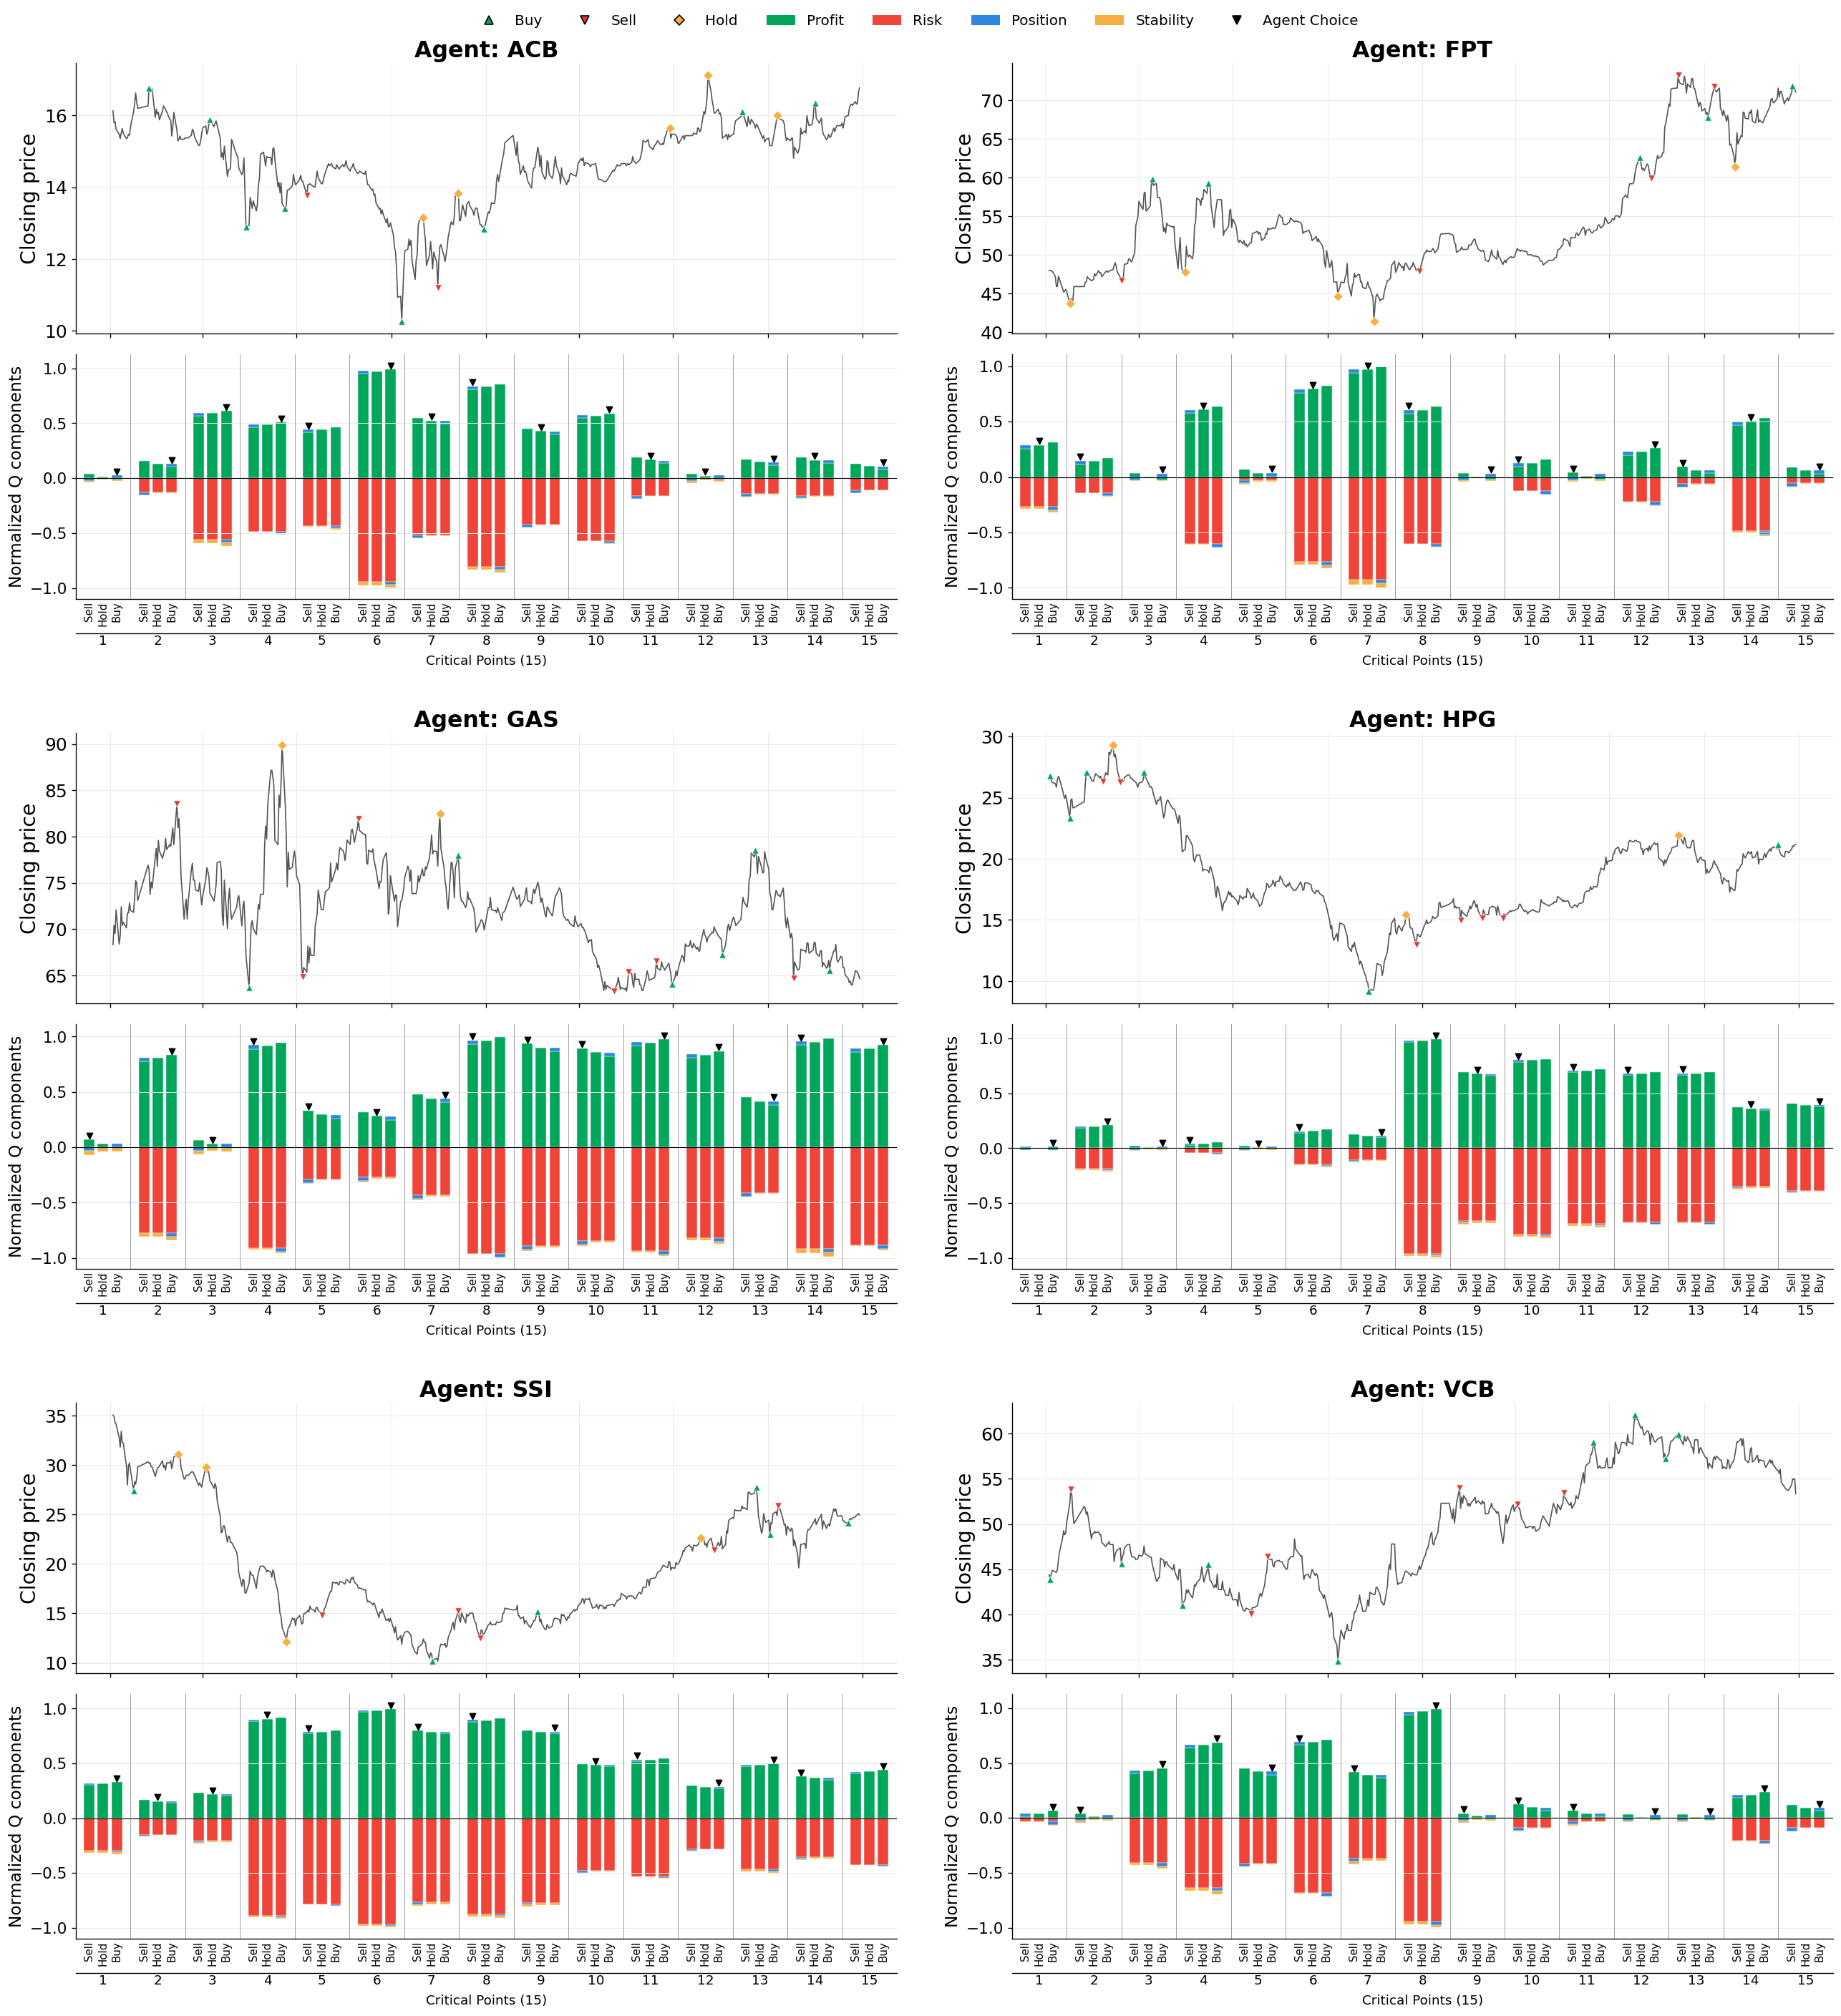

In [5]:
# Toàn bộ pipeline RDX -> MSX+ và biểu đồ thống kê nằm trong một cell.
MSX_COMPONENTS = ('Profit', 'Risk', 'Position', 'Stability')
MSX_TOP_K = 15
INITIAL_BALANCE, TRANSACTION_FEE = 1000.0, 0.001


def replay_greedy_policy(agent):
    """Replay Q-greedy với action mask giống pipeline thực nghiệm chính."""
    cash, position = INITIAL_BALANCE, 0
    states, action_indices, rewards = [], [], []
    for step in range(len(agent.test_frame) - 1):
        row = agent.test_frame.iloc[step]
        price = float(row['close'])
        state = np.asarray([
            price, cash, position, row['MACD'], row['RSI'], row['CCI'], row['ADX']
        ], dtype=np.float32)
        max_buy = int(cash // (price * (1.0 + TRANSACTION_FEE)))
        valid = np.asarray([
            -position <= int(action) <= max_buy for action in ACTION_VALUES
        ], dtype=bool)
        q_values = agent.q_values(state)[0]
        action_index = int(np.argmax(np.where(valid, q_values, -np.inf)))
        requested = int(ACTION_VALUES[action_index])
        executed = min(requested, max_buy) if requested > 0 else -min(-requested, position)
        value_before = cash + position * price
        cash -= executed * price + abs(executed) * price * TRANSACTION_FEE
        position += executed
        next_price = float(agent.test_frame.iloc[step + 1]['close'])
        states.append(state)
        action_indices.append(action_index)
        rewards.append(cash + position * next_price - value_before)
    return (np.asarray(states, np.float32), np.asarray(action_indices, np.int64),
            np.asarray(rewards, np.float64))


def decompose_q_balanced(agent, states):
    """Phân rã Q thành Profit, Risk, Position, Stability theo RDX tham chiếu."""
    prices = agent.test_frame['close'].to_numpy(float)[:len(states)]
    returns = pd.Series(prices).pct_change().fillna(0.0).to_numpy()
    running_max = np.maximum.accumulate(prices)
    ma10 = pd.Series(prices).rolling(10, min_periods=1).mean().to_numpy()
    components = np.zeros((len(states), len(ACTION_VALUES), len(MSX_COMPONENTS)))
    for step, state in enumerate(states):
        q_values = agent.q_values(state)[0]
        portfolio = max(float(state[1] + state[2] * prices[step]), 10.0)
        drawdown = (prices[step] - running_max[step]) / max(running_max[step], 1e-9)
        trend = np.sign(prices[step] - ma10[step])
        for action_index, action in enumerate(ACTION_VALUES):
            risk = -0.5 * abs(drawdown)
            stability = -0.1 * abs(returns[step])
            position_score = (0.0 if action == 0 else
                              0.005 if np.sign(action) == trend else -0.005)
            normalized_q = float(q_values[action_index]) / portfolio
            profit = normalized_q - risk - position_score - stability
            components[step, action_index] = (profit, risk, position_score, stability)
    return components


def select_critical_points(data, action_indices, top_k=15):
    prices = data['close'].to_numpy(float)[:len(action_indices)]
    actions = ACTION_VALUES[action_indices]
    running_max = np.maximum.accumulate(prices)
    drawdown = (prices - running_max) / np.maximum(running_max, 1e-9)
    priority = [int(np.argmin(prices)), int(np.argmin(drawdown))]
    reversals = np.concatenate([
        argrelextrema(prices, np.greater, order=10)[0],
        argrelextrema(prices, np.less, order=10)[0],
    ]).astype(int)
    median = float(np.median(prices))
    priority += sorted(reversals, key=lambda i: abs(prices[i] - median), reverse=True)
    changes = np.abs(np.diff(actions))
    shifts = (np.where(changes >= 3)[0] + 1).astype(int)
    priority += sorted(shifts, key=lambda i: changes[i - 1], reverse=True)
    priority += list(np.argsort(drawdown))  # Bổ sung để luôn đủ Top-K.
    selected = []
    for index in priority:
        if int(index) not in selected:
            selected.append(int(index))
        if len(selected) == min(top_k, len(prices)):
            break
    return sorted(selected)


def minimal_sufficient_explanation(selected_vector, compared_vector):
    """MSX+: tập lợi thế nhỏ nhất có tổng lớn hơn toàn bộ bất lợi."""
    delta = np.asarray(selected_vector) - np.asarray(compared_vector)
    positive = sorted(
        [(index, value) for index, value in enumerate(delta) if value > 0],
        key=lambda pair: pair[1], reverse=True,
    )
    disadvantage = float(np.abs(delta[delta <= 0]).sum())
    members, advantage = [], 0.0
    for index, value in positive:
        members.append(index)
        advantage += float(value)
        if advantage > disadvantage:
            break
    return delta, members, advantage > disadvantage, advantage, disadvantage


explanation_rows, component_rows, rollout_rows = [], [], []
agent_msx_plot_data = {}
for ticker, agent in xai_agents.items():
    states, chosen_indices, rewards = replay_greedy_policy(agent)
    decomposed = decompose_q_balanced(agent, states)
    critical_points = select_critical_points(agent.test_frame, chosen_indices, MSX_TOP_K)
    agent_msx_plot_data[ticker] = {
        'states': states, 'actions': chosen_indices,
        'decomposed': decomposed, 'critical_points': critical_points,
    }
    for rank, step in enumerate(critical_points, start=1):
        chosen_index = int(chosen_indices[step])
        chosen_action = int(ACTION_VALUES[chosen_index])
        if chosen_action == 0:
            comparisons = ((10, 'Strong Buy (+5)'), (0, 'Strong Sell (-5)'))
        else:
            opposite = int(np.flatnonzero(ACTION_VALUES == -chosen_action)[0])
            comparisons = ((5, 'Hold (0)'), (opposite, f'Opposite ({-chosen_action:+d})'))
        for compared_index, compared_label in comparisons:
            delta, members, sufficient, advantage, disadvantage = (
                minimal_sufficient_explanation(
                    decomposed[step, chosen_index], decomposed[step, compared_index]
                )
            )
            explanation_id = f'{ticker}-{rank:02d}-{compared_index:02d}'
            names = tuple(MSX_COMPONENTS[index] for index in members)
            explanation_rows.append({
                'explanation_id': explanation_id, 'ticker': ticker,
                'critical_rank': rank, 'step': step,
                'time': agent.test_frame['time'].iloc[step],
                'selected_action': chosen_action,
                'compared_action': int(ACTION_VALUES[compared_index]),
                'compared_label': compared_label,
                'msx_components': ', '.join(names) if names else 'None',
                'msx_size': len(members), 'sufficient': bool(sufficient),
                'total_advantage': advantage, 'total_disadvantage': disadvantage,
            })
            for component_index, component in enumerate(MSX_COMPONENTS):
                component_rows.append({
                    'explanation_id': explanation_id, 'ticker': ticker,
                    'component': component, 'delta': float(delta[component_index]),
                    'in_msx': component_index in members,
                })
    rollout_rows.append({
        'ticker': ticker, 'states': len(states),
        'critical_points': len(critical_points),
        'comparisons': len(critical_points) * 2,
        'total_reward': float(rewards.sum()),
    })

msx_explanations = pd.DataFrame(explanation_rows)
msx_component_details = pd.DataFrame(component_rows)
msx_rollout_inventory = pd.DataFrame(rollout_rows)
# Biểu đồ 6 agent: mỗi agent gồm đường giá và cột phân rã tại 15 điểm.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

component_colors = {
    'Profit': '#00A65A', 'Risk': '#F04438',
    'Position': '#2E86DE', 'Stability': '#F5B041',
}
comparison_actions = (('Sell', 0), ('Hold', 5), ('Buy', 10))
action_offset = {'Sell': 0, 'Hold': 1, 'Buy': 2}

plt.rcParams.update({'font.size': 100})  # Thay 12 bằng kích cỡ chữ bạn muốn
fig_msx = plt.figure(figsize=(22, 24), dpi=120)
outer_grid = fig_msx.add_gridspec(
    3, 2, left=0.055, right=0.985, top=0.955, bottom=0.045,
    wspace=0.14, hspace=0.25,
)

for agent_index, ticker in enumerate(TICKERS):
    agent = xai_agents[ticker]
    plot_data = agent_msx_plot_data[ticker]
    chosen_indices = plot_data['actions']
    decomposed = plot_data['decomposed']
    critical_points = plot_data['critical_points']
    data = agent.test_frame

    inner_grid = outer_grid[agent_index // 2, agent_index % 2].subgridspec(
        2, 1, height_ratios=(1.05, 0.95), hspace=0.08
    )
    ax_price = fig_msx.add_subplot(inner_grid[0])
    ax_bar = fig_msx.add_subplot(inner_grid[1])

    critical_q = decomposed[critical_points]
    max_abs_q = float(np.max(np.abs(critical_q))) if critical_q.size else 1.0
    max_abs_q = max(max_abs_q, 1e-12)
    critical_times = pd.to_datetime(data.iloc[critical_points]['time']).to_numpy()
    critical_prices = data.iloc[critical_points]['close'].to_numpy(float)
    critical_actions = ACTION_VALUES[chosen_indices[critical_points]]

    ax_price.plot(data['time'], data['close'], color='#555555', linewidth=1.0)
    for mask, marker, color in (
        (critical_actions > 0, '^', '#00A65A'),
        (critical_actions < 0, 'v', '#E53935'),
        (critical_actions == 0, 'D', '#F5B041'),
    ):
        ax_price.scatter(
            critical_times[mask], critical_prices[mask], s=32, marker=marker,
            color=color, edgecolor='white', linewidth=0.45, zorder=4,
        )
    ax_price.set_title(f'Agent: {ticker}', fontsize=19, fontweight='bold', pad=5)
    ax_price.set_ylabel('Closing price', fontsize=17)
    ax_price.tick_params(axis='both', labelsize=15)
    ax_price.tick_params(axis='x', labelbottom=False)
    ax_price.grid(True, color='#E8E8E8', linewidth=0.6)
    ax_price.spines[['top', 'right']].set_visible(False)

    bar_positions, bar_labels = [], []
    values_by_component = {component: [] for component in MSX_COMPONENTS}
    group_centers, choice_x, choice_y = [], [], []
    for point_index, step in enumerate(critical_points):
        group_start = point_index * 4
        group_centers.append(group_start + 1)
        chosen_action = int(ACTION_VALUES[chosen_indices[step]])
        selected_label = 'Buy' if chosen_action > 0 else 'Sell' if chosen_action < 0 else 'Hold'
        selected_vector = None
        for offset, (action_label, action_index) in enumerate(comparison_actions):
            position = group_start + offset
            vector = decomposed[step, action_index] / max_abs_q
            bar_positions.append(position); bar_labels.append(action_label)
            for component_index, component in enumerate(MSX_COMPONENTS):
                values_by_component[component].append(float(vector[component_index]))
            if action_label == selected_label:
                selected_vector = vector
        choice_x.append(group_start + action_offset[selected_label])
        choice_y.append(float(np.maximum(selected_vector, 0.0).sum()) + 0.035)

    bar_positions = np.asarray(bar_positions, dtype=float)
    positive_bottom = np.zeros(len(bar_positions))
    negative_bottom = np.zeros(len(bar_positions))
    for component in MSX_COMPONENTS:
        values = np.asarray(values_by_component[component], dtype=float)
        bottoms = np.where(values >= 0, positive_bottom, negative_bottom)
        ax_bar.bar(
            bar_positions, values, width=0.78, bottom=bottoms,
            color=component_colors[component], edgecolor='white', linewidth=0.25,
        )
        positive_bottom += np.maximum(values, 0.0)
        negative_bottom += np.minimum(values, 0.0)

    ax_bar.scatter(choice_x, choice_y, marker='v', s=24, color='black', zorder=5)
    ax_bar.axhline(0, color='black', linewidth=0.7)
    # Đổi -0.5 thành -1.0 để căn đều 2 bên (khoảng cách biên trái và biên phải đều là 1.0)
    for boundary in np.arange(-1.0, len(critical_points) * 4, 4):
        ax_bar.axvline(boundary, color='#777777', linewidth=0.55, alpha=0.75)
    # Cập nhật lại giới hạn hiển thị của trục X cho khít với các đường phân cách
    ax_bar.set_xlim(-1.0, len(critical_points) * 4 - 1.0)
    ax_bar.set_ylabel('Normalized Q components', fontsize=14)
    ax_bar.set_xticks(bar_positions, bar_labels, rotation=90, fontsize=9)
    ax_bar.tick_params(axis='x', length=0, pad=2)
    ax_bar.tick_params(axis='y', labelsize=13)
    ax_bar.grid(axis='y', color='#E8E8E8', linewidth=0.6)
    ax_bar.spines[['top', 'right']].set_visible(False)

    # Trục thứ hai dành riêng cho số điểm, tránh trộn/lệch Sell-Hold-Buy.
    point_axis = ax_bar.secondary_xaxis('bottom')
    point_axis.spines['bottom'].set_position(('outward', 29))
    point_axis.set_xticks(group_centers, [str(i) for i in range(1, len(critical_points) + 1)])
    point_axis.tick_params(axis='x', length=0, labelsize=11, pad=1)
    point_axis.set_xlabel(f'Critical Points ({len(critical_points)})', fontsize=11, labelpad=6)

legend_handles = [
    Line2D([0], [0], marker='^', color='none', markerfacecolor='#00A65A', label='Buy', markersize=7),
    Line2D([0], [0], marker='v', color='none', markerfacecolor='#E53935', label='Sell', markersize=7),
    Line2D([0], [0], marker='D', color='none', markerfacecolor='#F5B041', label='Hold', markersize=6),
    *[Patch(facecolor=component_colors[name], label=name) for name in MSX_COMPONENTS],
    Line2D([0], [0], marker='v', color='none', markerfacecolor='black', label='Agent Choice', markersize=7),
]
fig_msx.legend(
    handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.985),
    ncol=8, frameon=False, fontsize=12,
)
plt.show()

## Chạy SHAP cho các checkpoint của thực nghiệm chính

File thực hiện mẫu theo Kernel SHAP: application\XAI_analysis\SHAP_2013_2017.ipynb. Cần 1 cell cho good và 1 cell cho bad period ở mỗi file test. Mỗi cell sẽ xuất ra 1 biểu đồ SHAP riêng, không tạo thêm file gì hết, chỉ xuất hình plot lên thành output trên notebook bằng seaborn cho visualization. Lấy Waterfall plot, Beeswarm plot và Summary plot. Mỗi checkpoint có 1 biểu đồ SHAP riêng, không tạo thêm file gì hết, chỉ xuất hình plot lên thành output trên notebook cho visualization.

### GOOD period

#### ACB

**Waterfall plot**

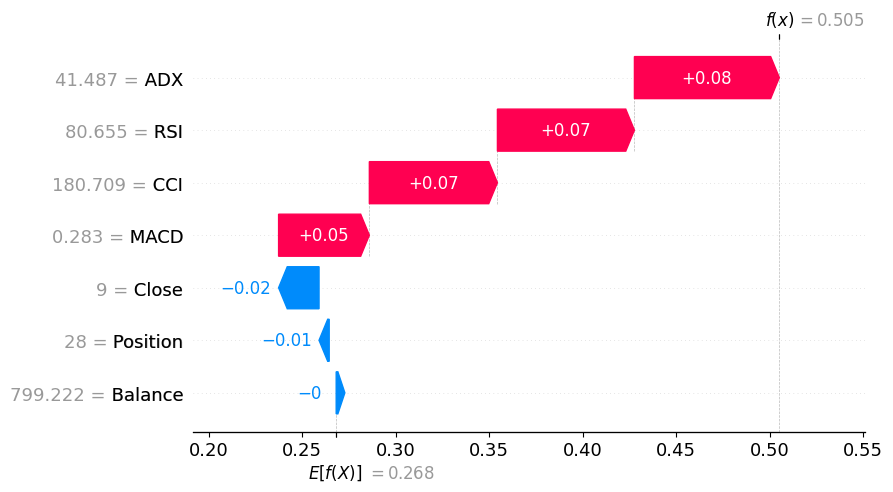

**Beeswarm plot**

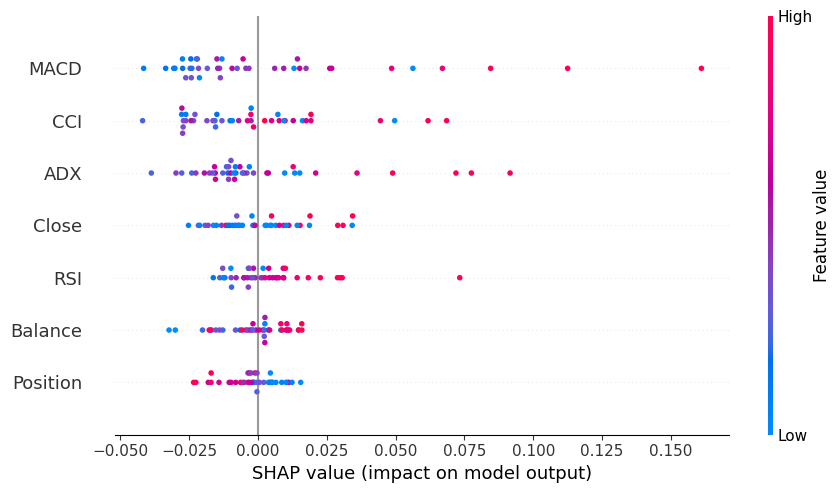

**Summary plot**

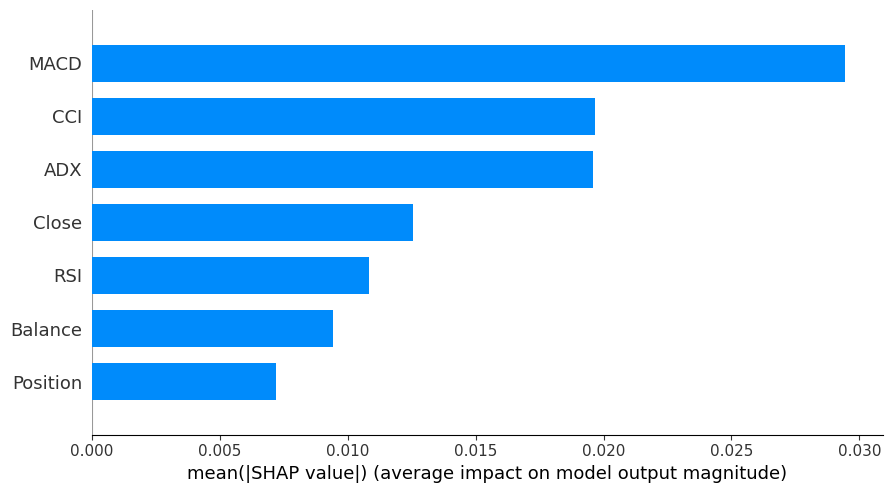

#### FPT

**Waterfall plot**

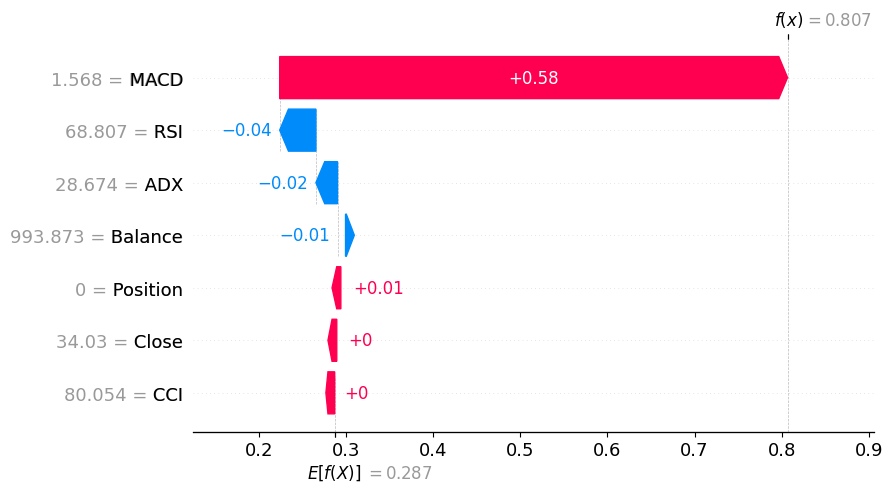

**Beeswarm plot**

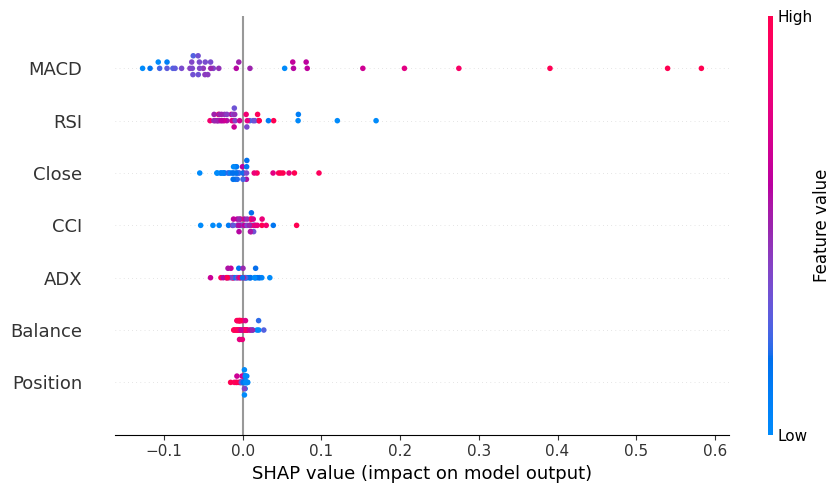

**Summary plot**

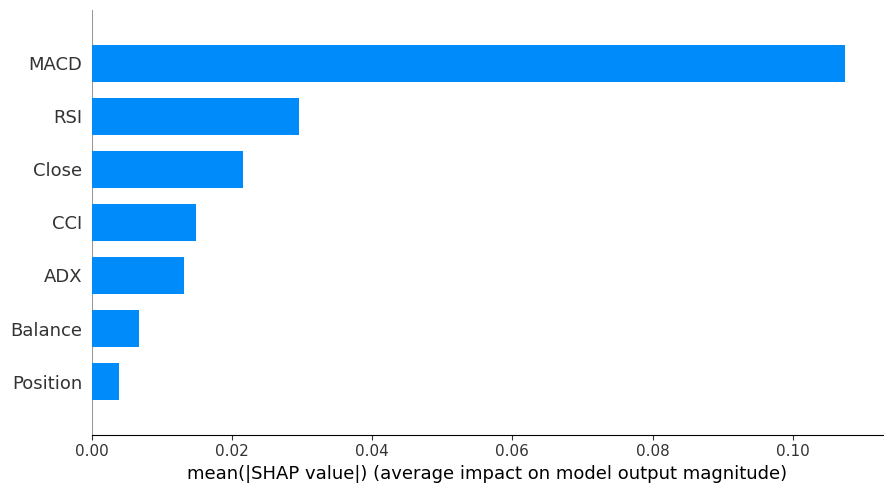

#### GAS

**Waterfall plot**

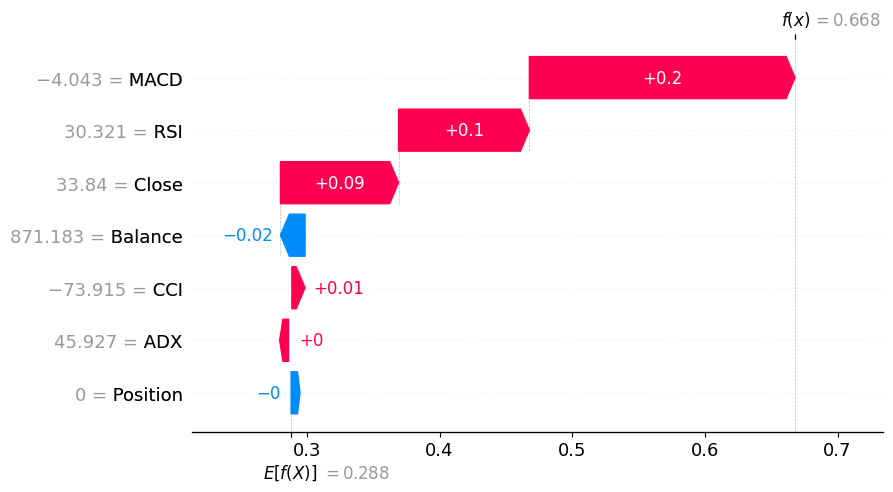

**Beeswarm plot**

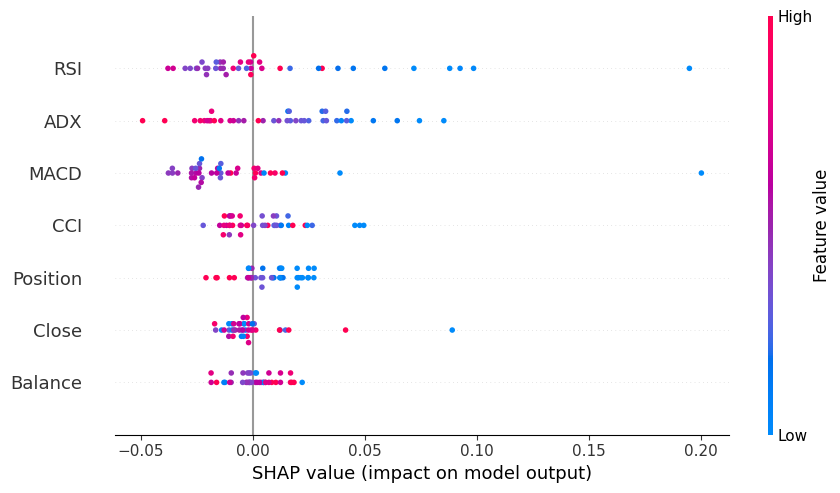

**Summary plot**

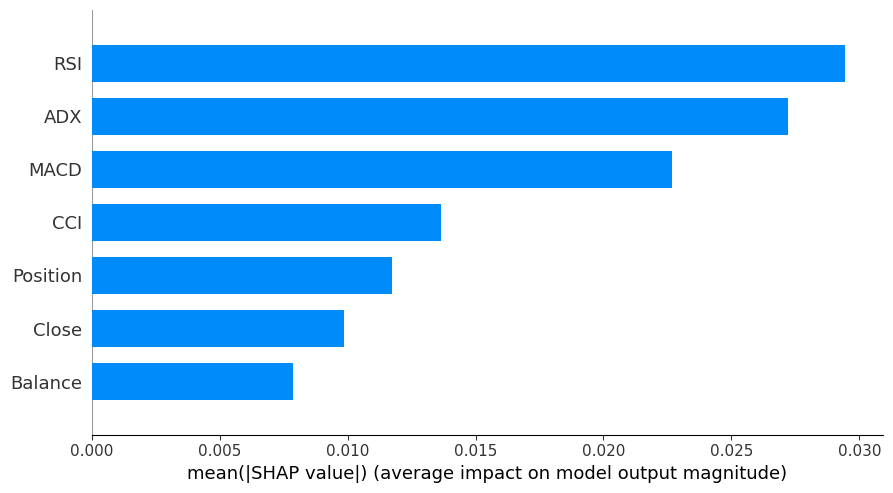

#### HPG

**Waterfall plot**

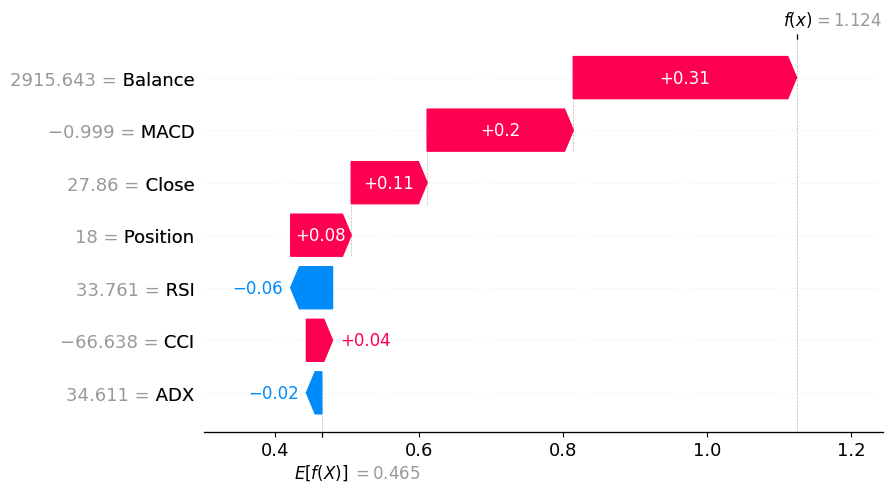

**Beeswarm plot**

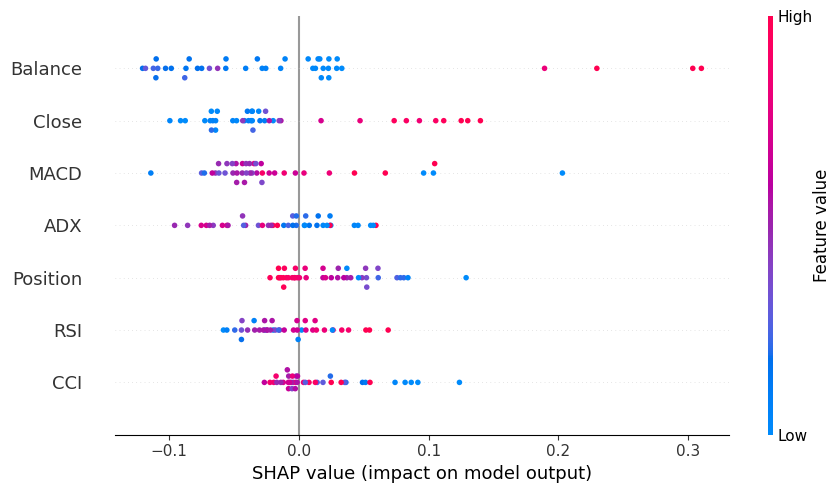

**Summary plot**

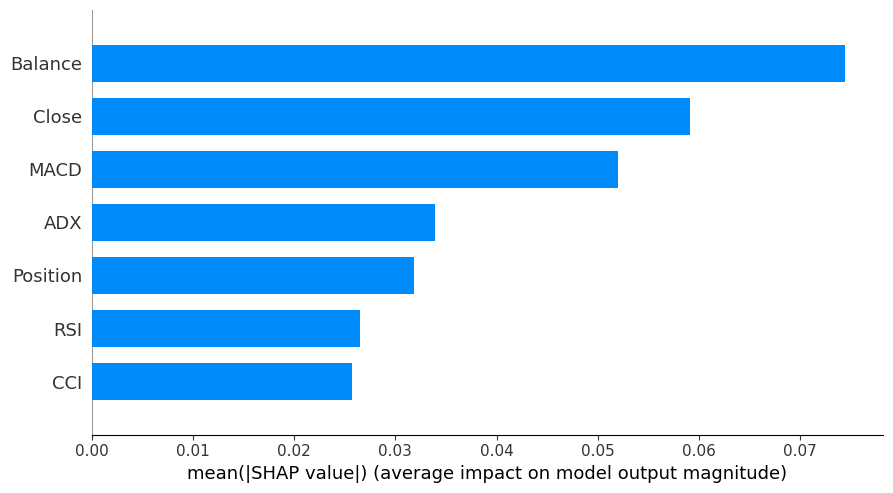

#### SSI

**Waterfall plot**

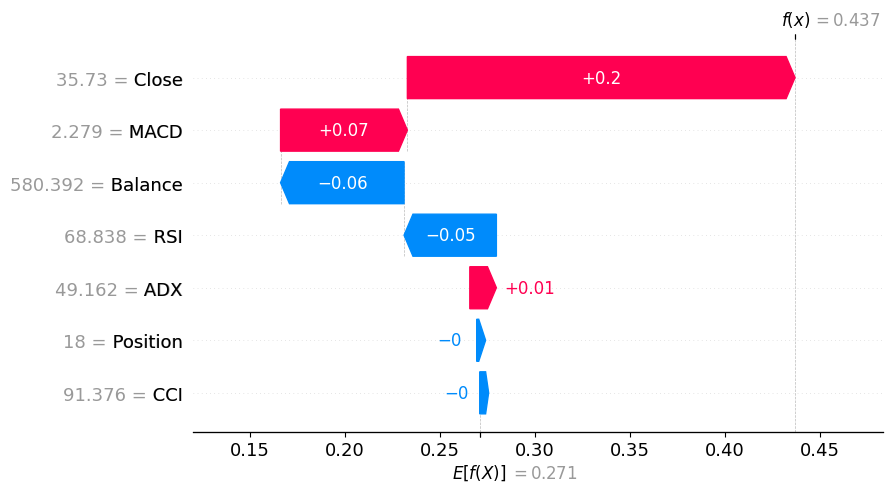

**Beeswarm plot**

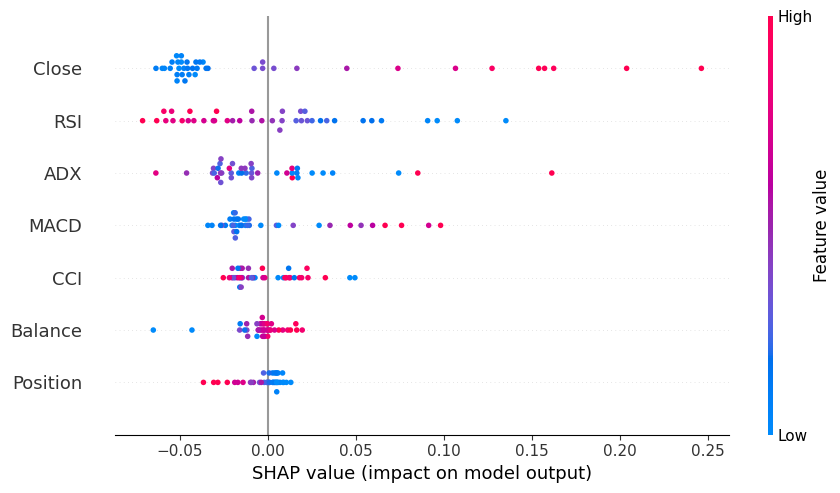

**Summary plot**

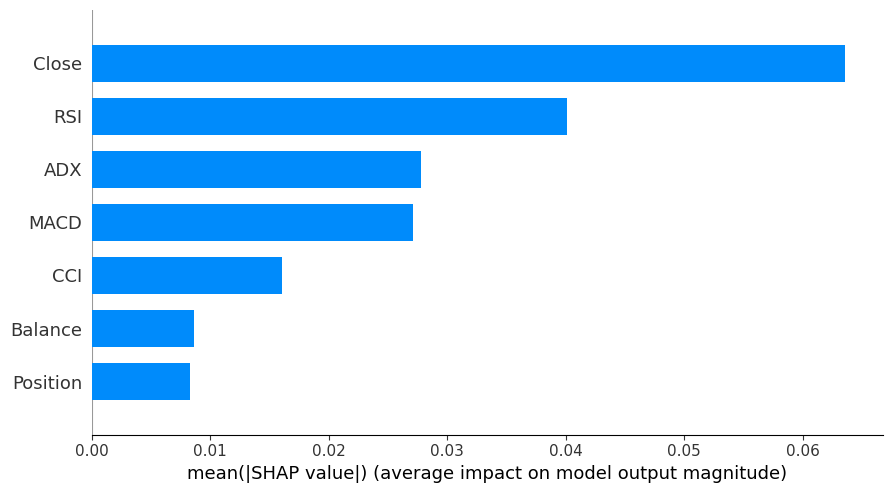

#### VCB

**Waterfall plot**

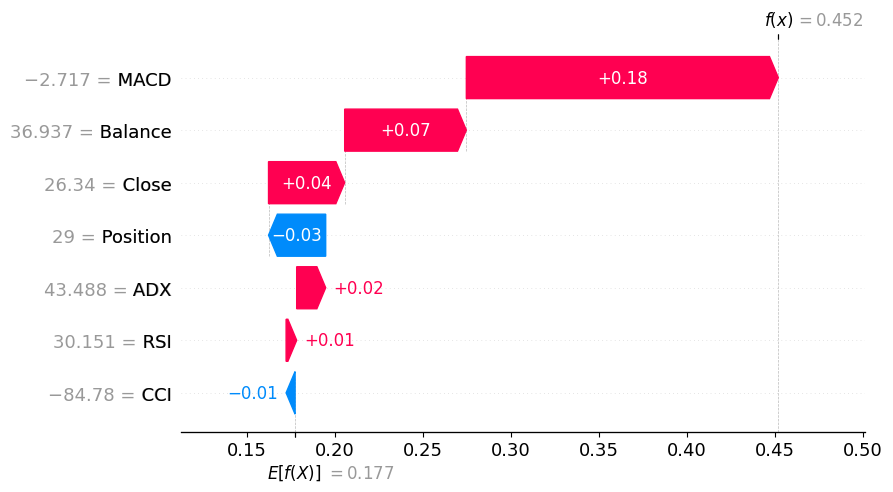

**Beeswarm plot**

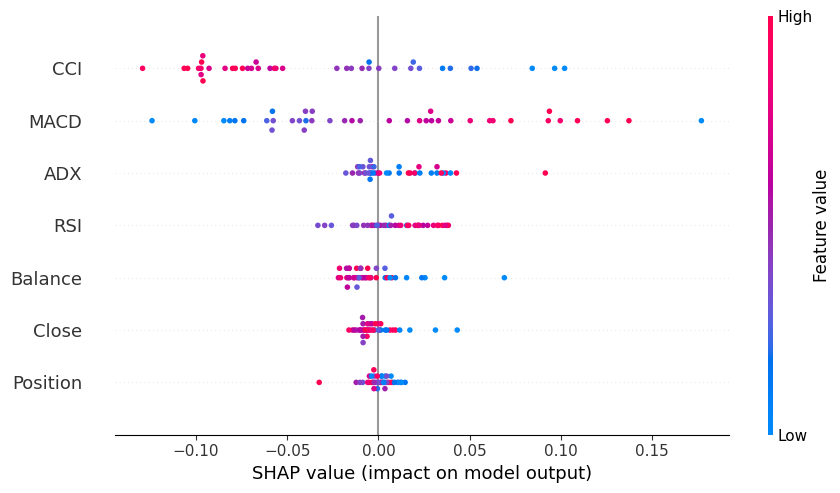

**Summary plot**

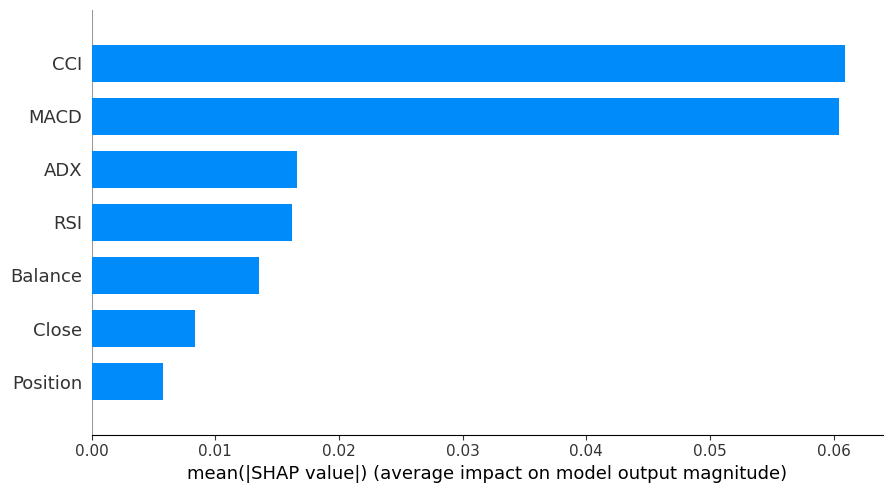

In [6]:
# Kernel SHAP cơ bản: giải thích max_a Q(s, a) của greedy policy cho GOOD period.
if not SHAP_AVAILABLE:
    raise ImportError('Chưa có package shap. Hãy cài bằng: pip install shap')

import shap
import matplotlib as mpl
from IPython.display import Markdown, display

SHAP_FEATURES = ('Close', 'Balance', 'Position', 'MACD', 'RSI', 'CCI', 'ADX')
SHAP_SAMPLE_COUNT = 40
SHAP_BACKGROUND_COUNT = 15
SHAP_NSAMPLES = 80


def collect_shap_states(agent, frame):
    """Replay greedy policy và trả về chuỗi raw states cho SHAP."""
    cash, position = 1000.0, 0
    states = []
    for step in range(len(frame) - 1):
        row = frame.iloc[step]
        price = float(row['close'])
        state = np.asarray([
            price, cash, position, row['MACD'], row['RSI'], row['CCI'], row['ADX']
        ], dtype=np.float32)
        max_buy = int(cash // (price * (1.0 + 0.001)))
        valid = np.asarray([
            -position <= int(action) <= max_buy for action in ACTION_VALUES
        ], dtype=bool)
        action_index = int(np.argmax(np.where(valid, agent.q_values(state)[0], -np.inf)))
        requested = int(ACTION_VALUES[action_index])
        executed = min(requested, max_buy) if requested > 0 else -min(-requested, position)
        cash -= executed * price + abs(executed) * price * 0.001
        position += executed
        states.append(state)
    return np.asarray(states, dtype=np.float32)


def kernel_shap_greedy_q(agent, states, seed):
    """Tạo KernelExplainer và SHAP values cho các trạng thái đại diện."""
    rng = np.random.default_rng(seed)
    sample_indices = np.linspace(
        0, len(states) - 1, min(SHAP_SAMPLE_COUNT, len(states)), dtype=int
    )
    background_indices = rng.choice(
        len(states), size=min(SHAP_BACKGROUND_COUNT, len(states)), replace=False
    )
    sample = states[sample_indices]
    background = states[background_indices]

    def predict_greedy_q(raw_batch):
        return agent.q_values(raw_batch).max(axis=1).astype(np.float64)

    explainer = shap.KernelExplainer(predict_greedy_q, background)
    values = np.asarray(
        explainer.shap_values(sample, nsamples=SHAP_NSAMPLES, silent=True),
        dtype=float,
    )
    if values.shape != sample.shape:
        raise ValueError(f'SHAP shape {values.shape} không khớp sample {sample.shape}.')

    base_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])
    return sample, values, sample_indices, base_value


def compute_shap_period(period, seed_offset=0):
    """Tính SHAP cho toàn bộ checkpoint trong một test period."""
    results = {}
    table_rows = []
    for ticker_index, ticker in enumerate(TICKERS):
        agent = xai_agents[ticker]
        frame = test_data[ticker][period]
        states = collect_shap_states(agent, frame)
        sample, values, sample_indices, base_value = kernel_shap_greedy_q(
            agent, states, seed=42 + seed_offset + ticker_index
        )
        results[ticker] = {
            'sample': sample,
            'values': values,
            'indices': sample_indices,
            'base_value': base_value,
        }
        for local_index, trajectory_index in enumerate(sample_indices):
            for feature_index, feature in enumerate(SHAP_FEATURES):
                table_rows.append({
                    'ticker': ticker,
                    'period': period.upper(),
                    'time': frame['time'].iloc[int(trajectory_index)],
                    'feature': feature,
                    'feature_value': float(sample[local_index, feature_index]),
                    'shap_value': float(values[local_index, feature_index]),
                })
    return results, pd.DataFrame(table_rows)


def show_basic_shap(period_results):
    """Mỗi checkpoint: Waterfall, Beeswarm và Summary bar chuẩn của SHAP."""
    plot_style = {
        'font.size': 9,
        'axes.titlesize': 10,
        'axes.labelsize': 9,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
    }
    for ticker in TICKERS:
        result = period_results[ticker]
        sample = result['sample']
        values = result['values']
        explanation = shap.Explanation(
            values=values,
            base_values=np.full(len(sample), result['base_value']),
            data=sample,
            feature_names=list(SHAP_FEATURES),
        )
        representative = int(np.argmax(np.abs(values).sum(axis=1)))

        display(Markdown(f'#### {ticker}'))
        with mpl.rc_context(plot_style):
            display(Markdown('**Waterfall plot**'))
            shap.plots.waterfall(
                explanation[representative], max_display=len(SHAP_FEATURES), show=False
            )
            plt.gcf().set_size_inches(9, 5)
            plt.tight_layout()
            plt.show()
            plt.close()

            display(Markdown('**Beeswarm plot**'))
            shap.plots.beeswarm(
                explanation, max_display=len(SHAP_FEATURES), show=False, plot_size=(9, 5)
            )
            plt.tight_layout()
            plt.show()
            plt.close()

            display(Markdown('**Summary plot**'))
            shap.summary_plot(
                values,
                sample,
                feature_names=list(SHAP_FEATURES),
                plot_type='bar',
                max_display=len(SHAP_FEATURES),
                show=False,
                plot_size=(9, 5),
            )
            plt.tight_layout()
            plt.show()
            plt.close()


shap_good_results, shap_good_table = compute_shap_period('good', seed_offset=0)
show_basic_shap(shap_good_results)


### BAD period

#### ACB

**Waterfall plot**

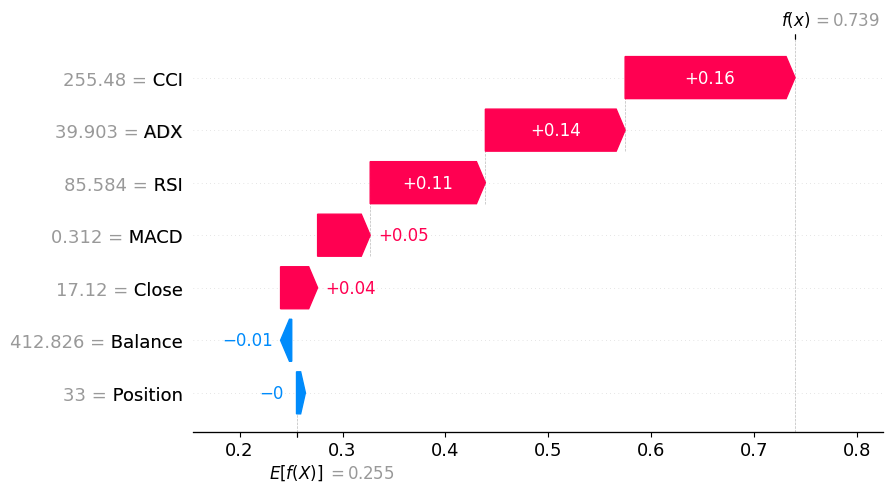

**Beeswarm plot**

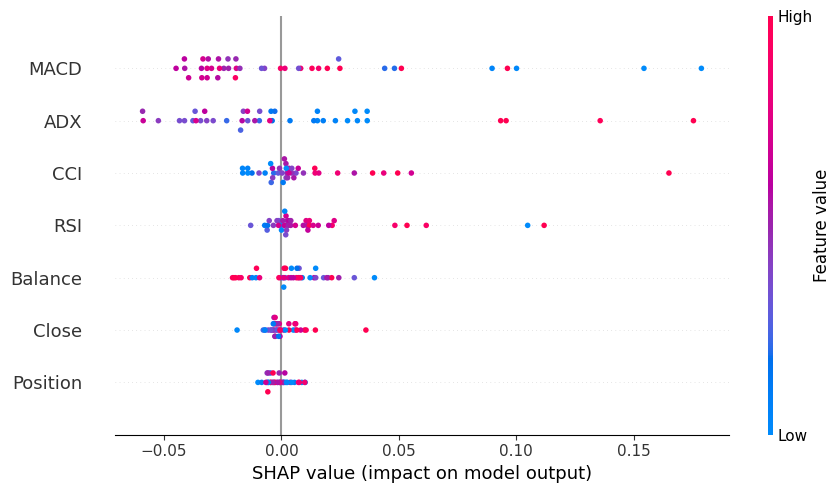

**Summary plot**

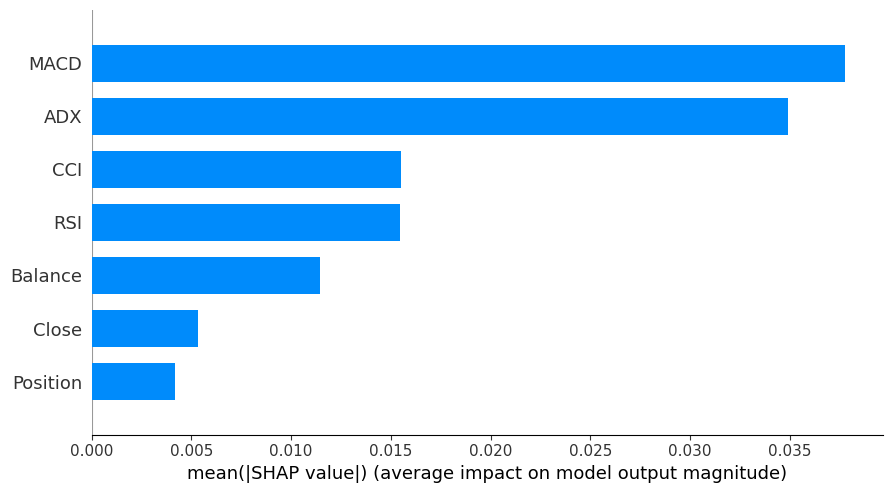

#### FPT

**Waterfall plot**

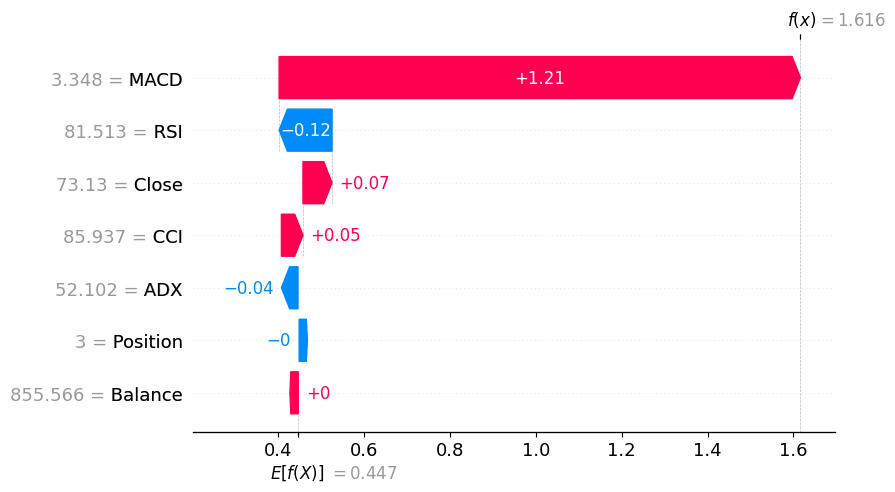

**Beeswarm plot**

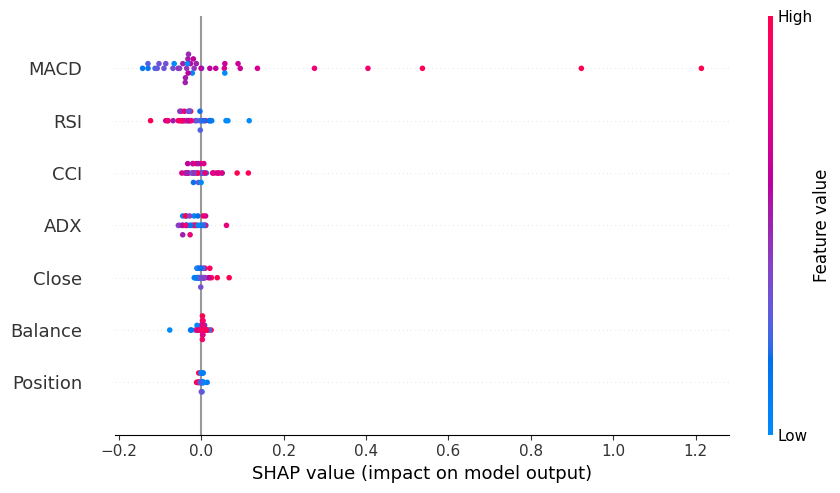

**Summary plot**

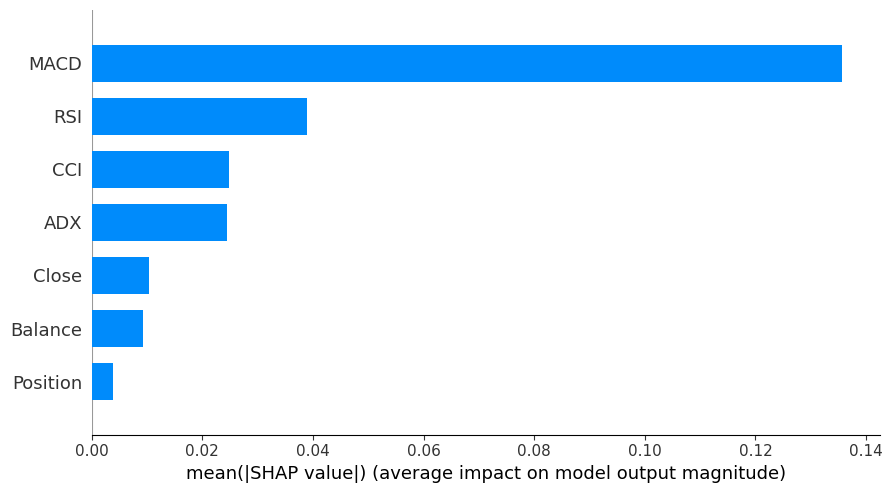

#### GAS

**Waterfall plot**

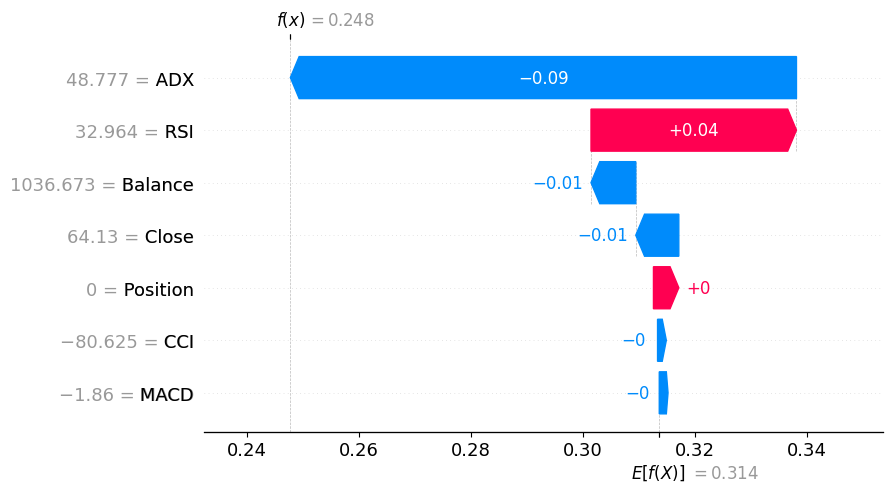

**Beeswarm plot**

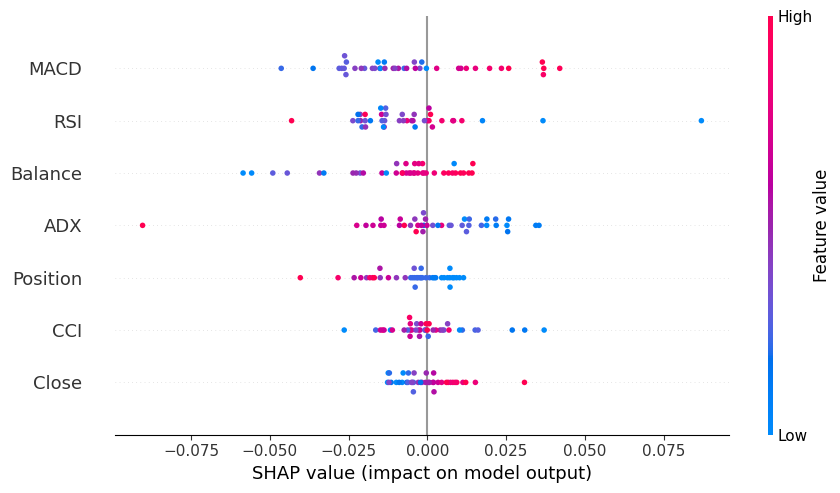

**Summary plot**

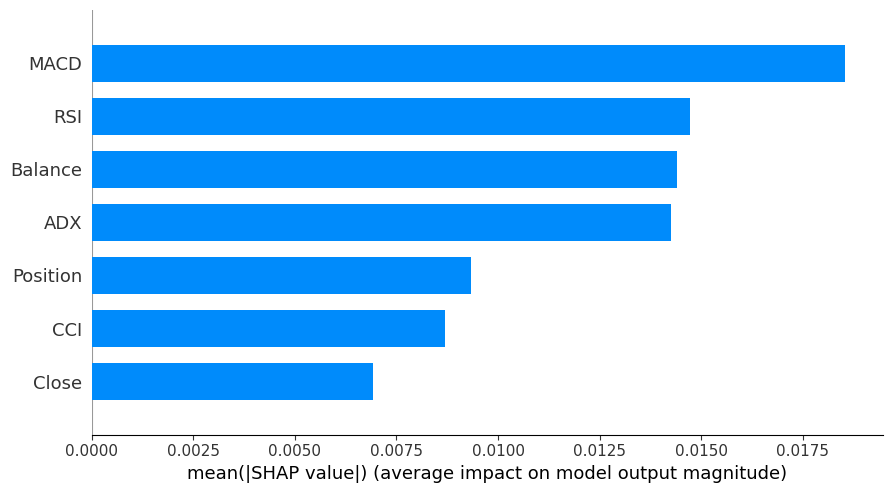

#### HPG

**Waterfall plot**

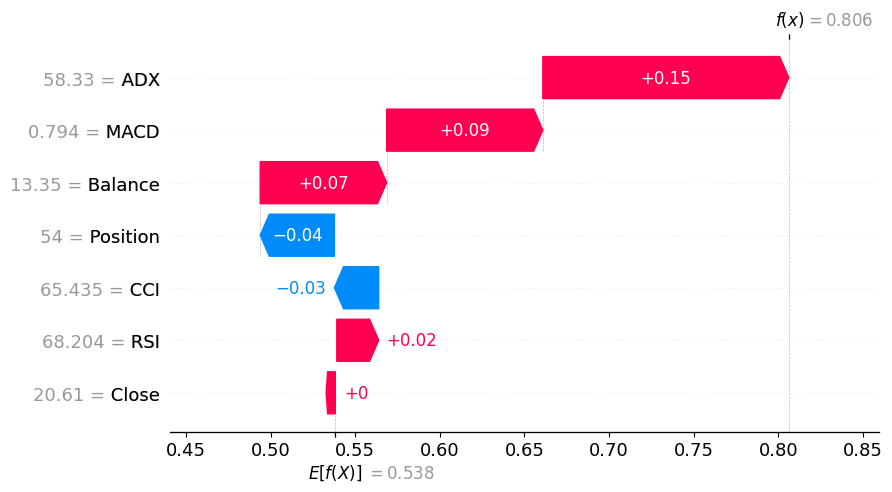

**Beeswarm plot**

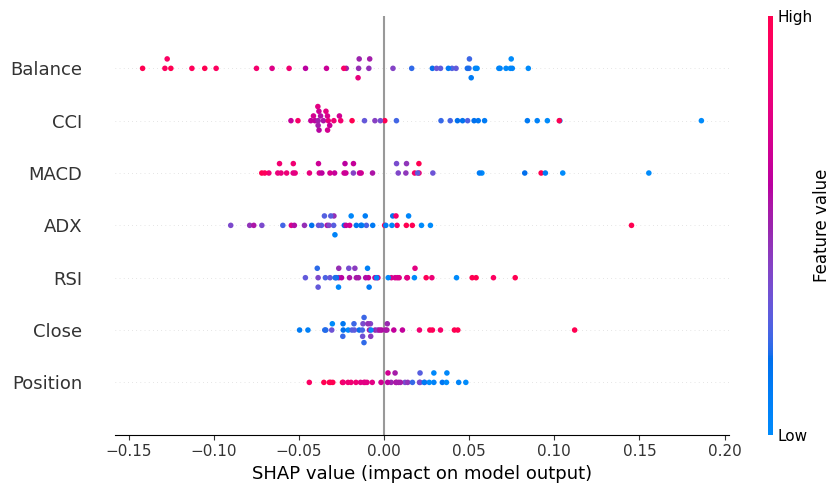

**Summary plot**

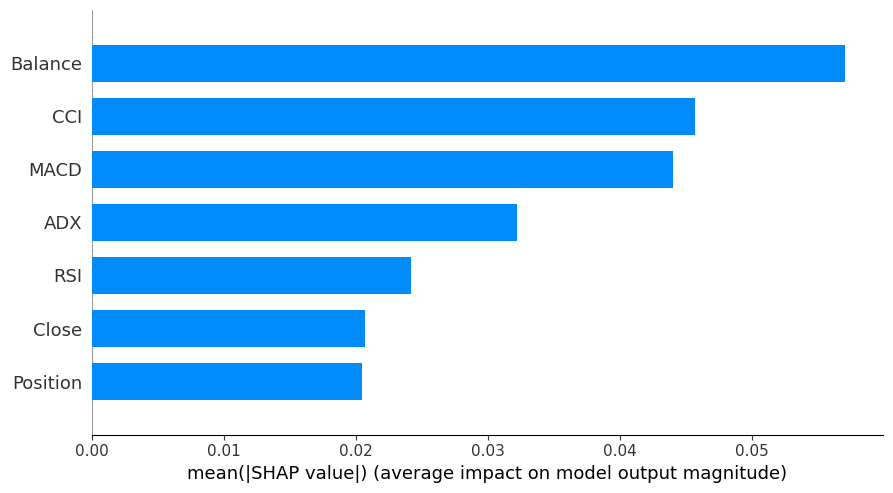

#### SSI

**Waterfall plot**

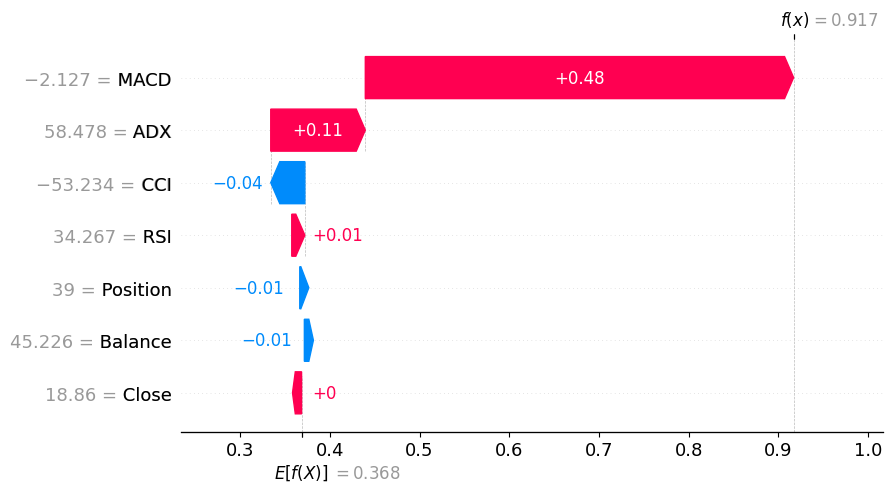

**Beeswarm plot**

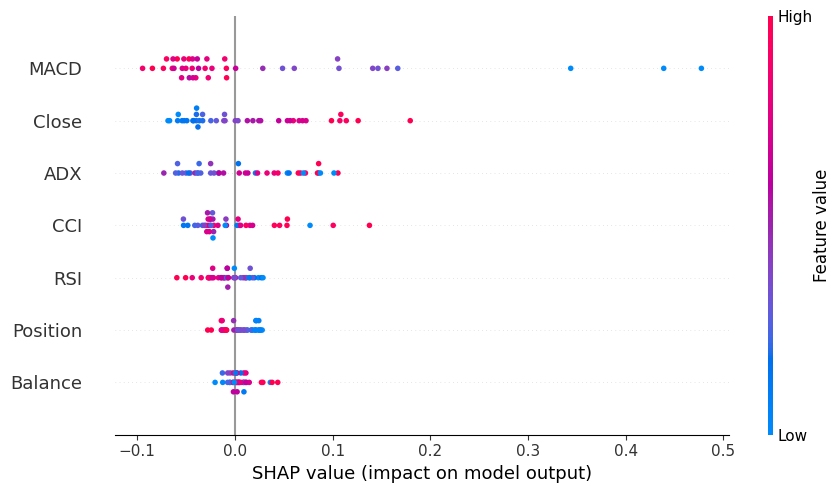

**Summary plot**

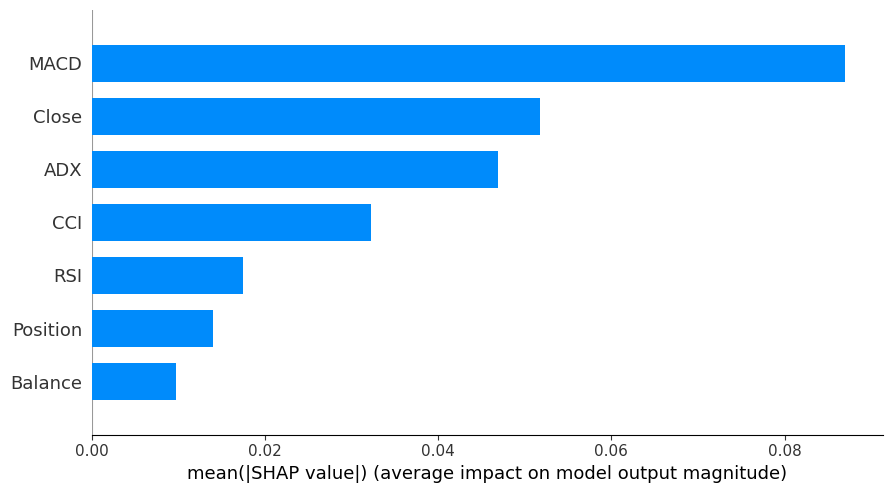

#### VCB

**Waterfall plot**

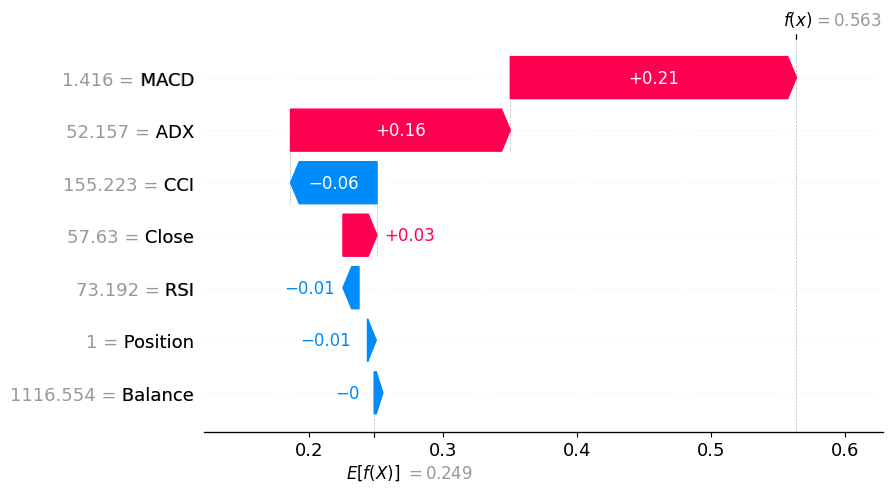

**Beeswarm plot**

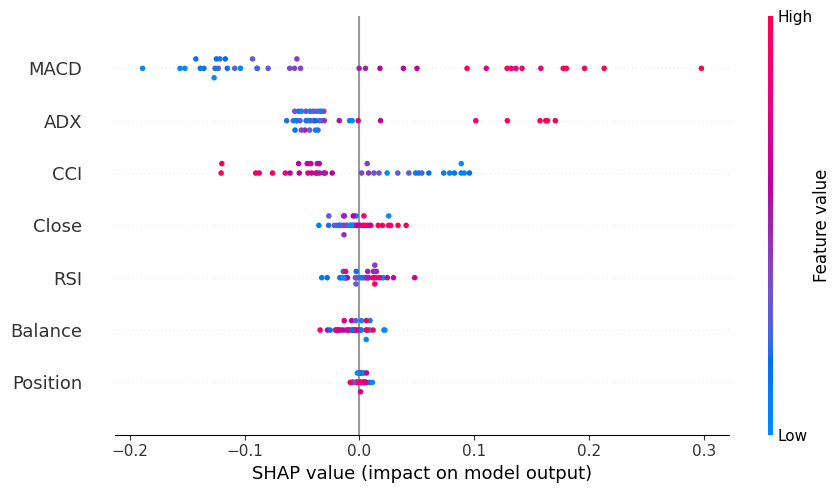

**Summary plot**

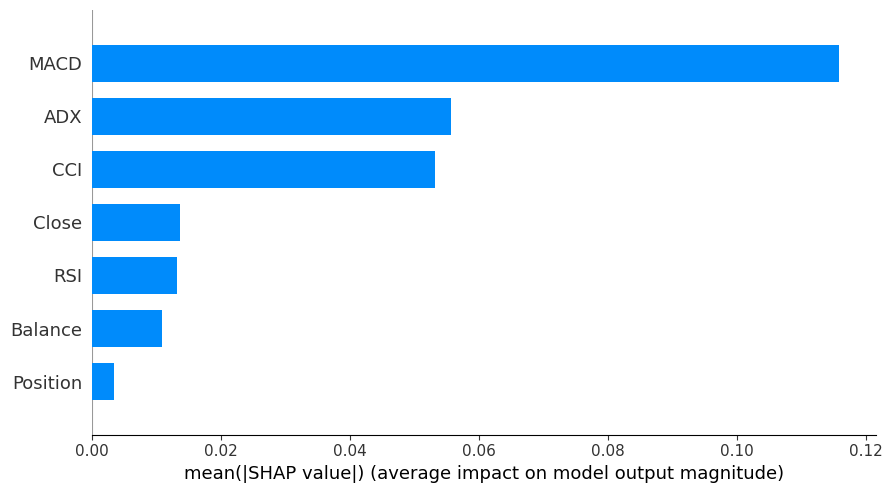

In [7]:
# Dùng lại đúng pipeline và ba biểu đồ SHAP cơ bản cho BAD period.
shap_bad_results, shap_bad_table = compute_shap_period('bad', seed_offset=100)
show_basic_shap(shap_bad_results)

# Bảng tổng hợp để thuận tiện phân tích tiếp ở các cell sau.
shap_results = {
    **{(ticker, 'good'): result for ticker, result in shap_good_results.items()},
    **{(ticker, 'bad'): result for ticker, result in shap_bad_results.items()},
}
shap_values_table = pd.concat(
    [shap_good_table, shap_bad_table], ignore_index=True
)

### Tổng hợp 1 loại plot của SHAP chứ kết quả 6 mã vào 1 hình.

### GOOD period — Waterfall plot

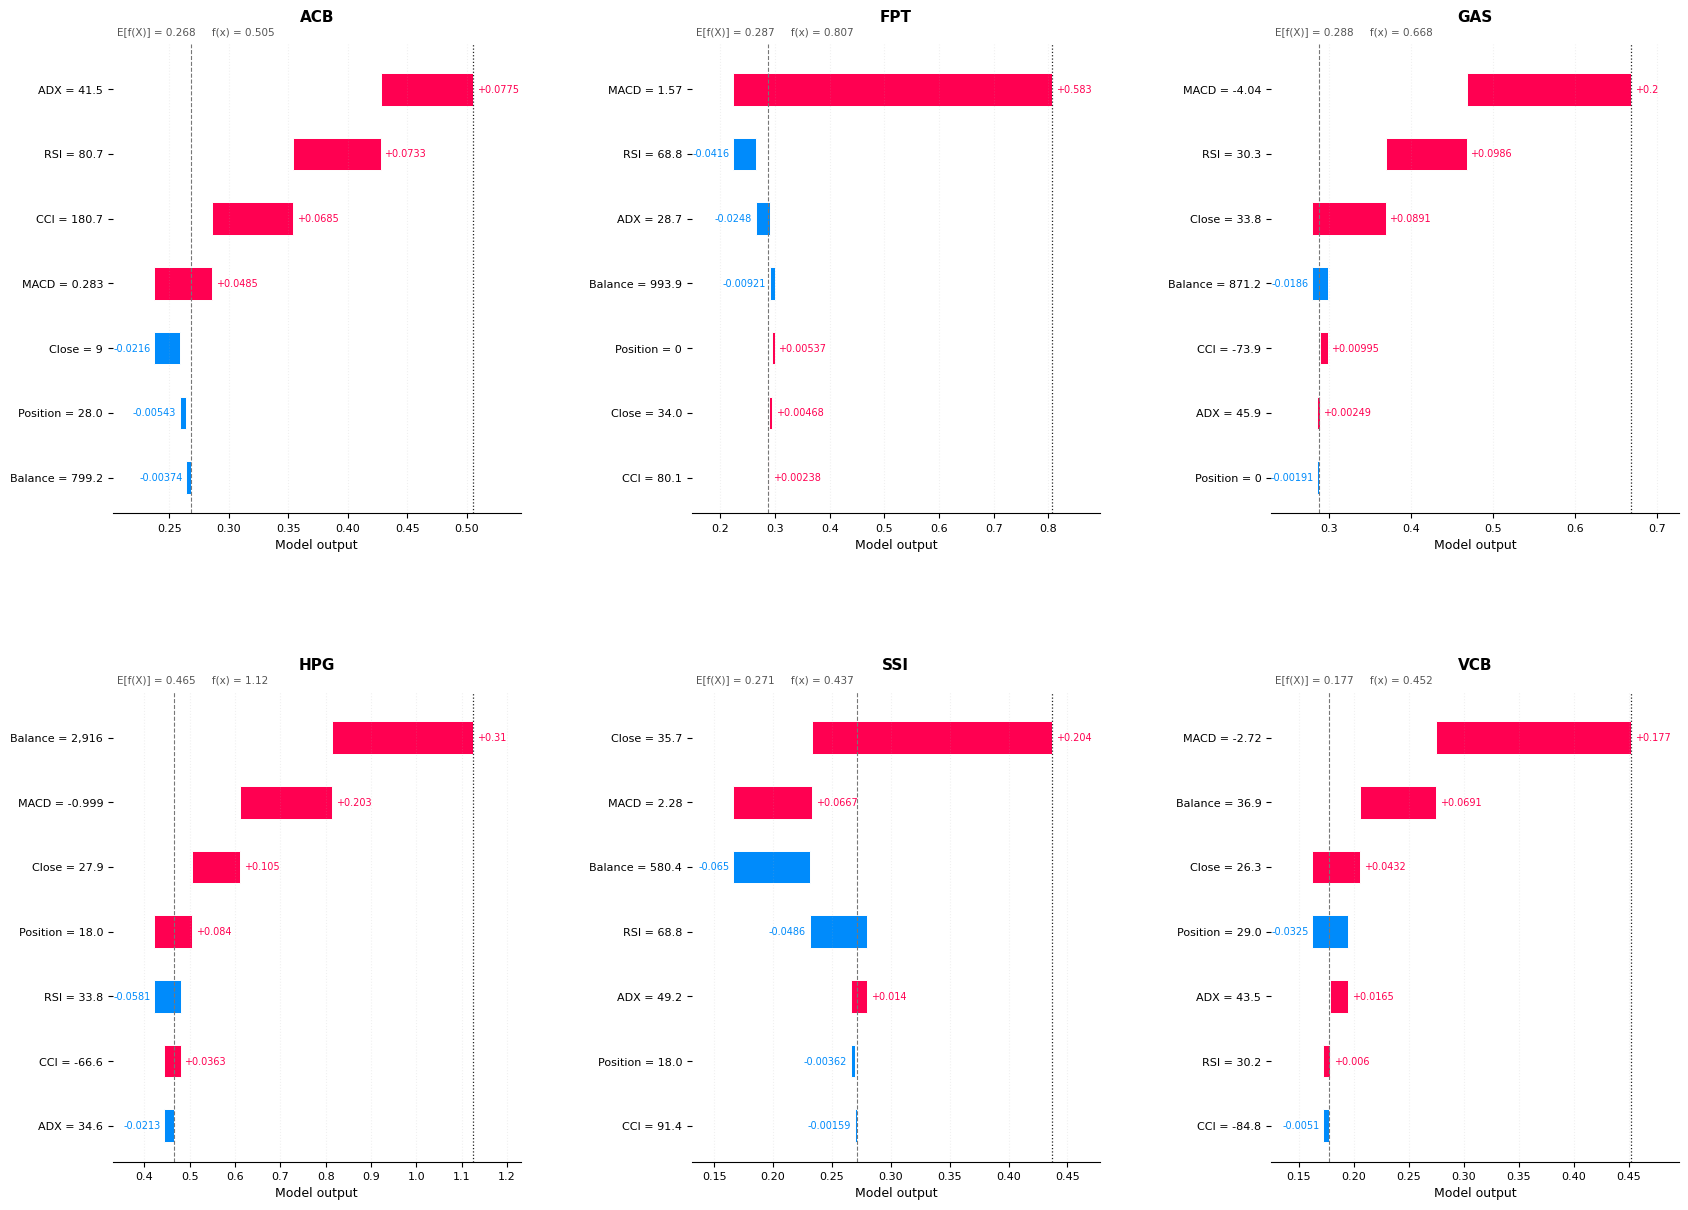

### GOOD period — Beeswarm plot

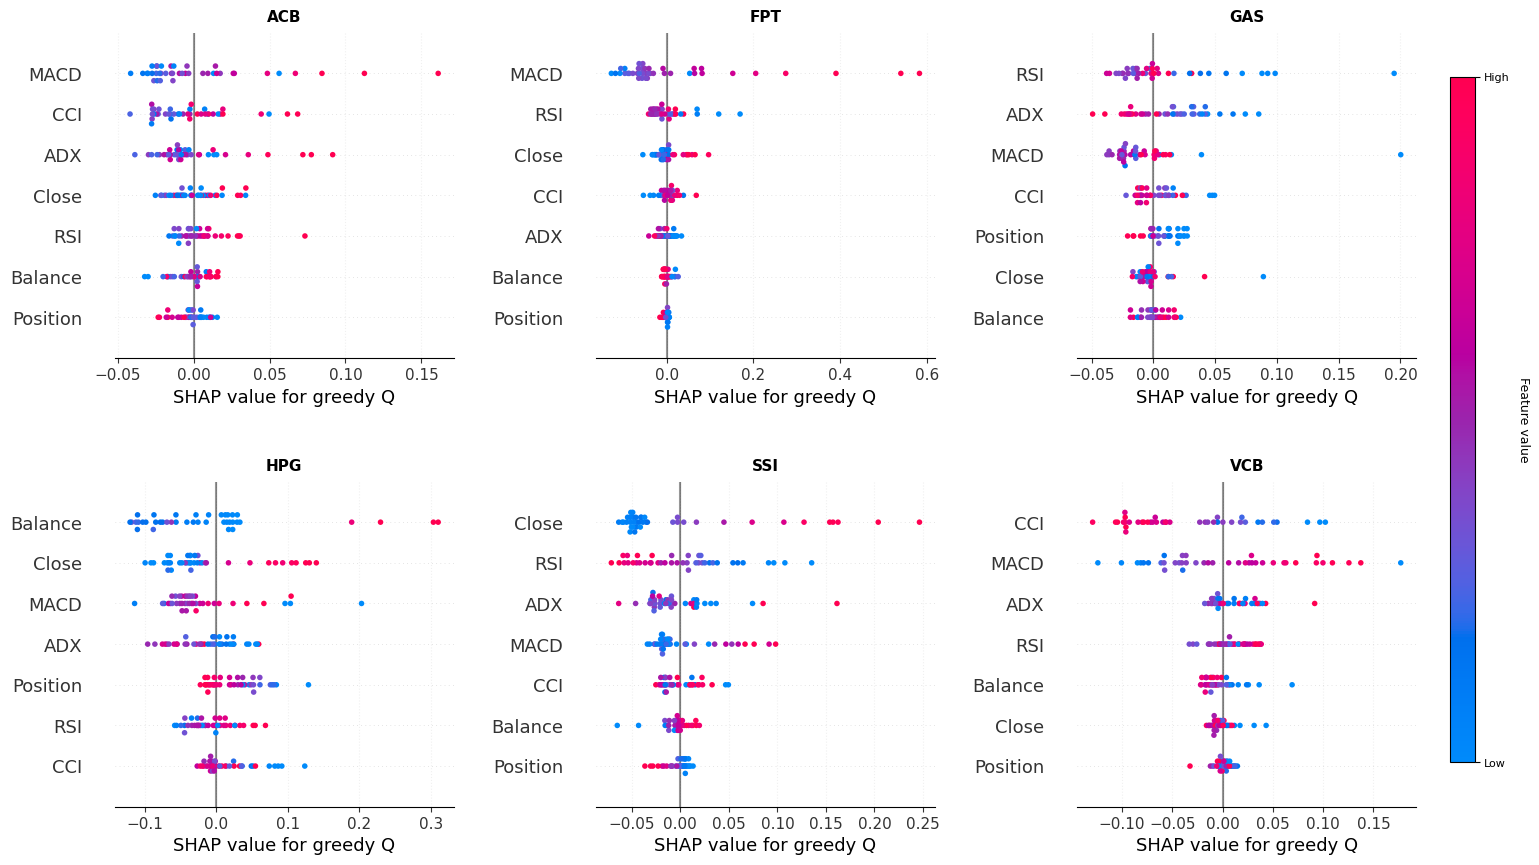

### GOOD period — Summary plot

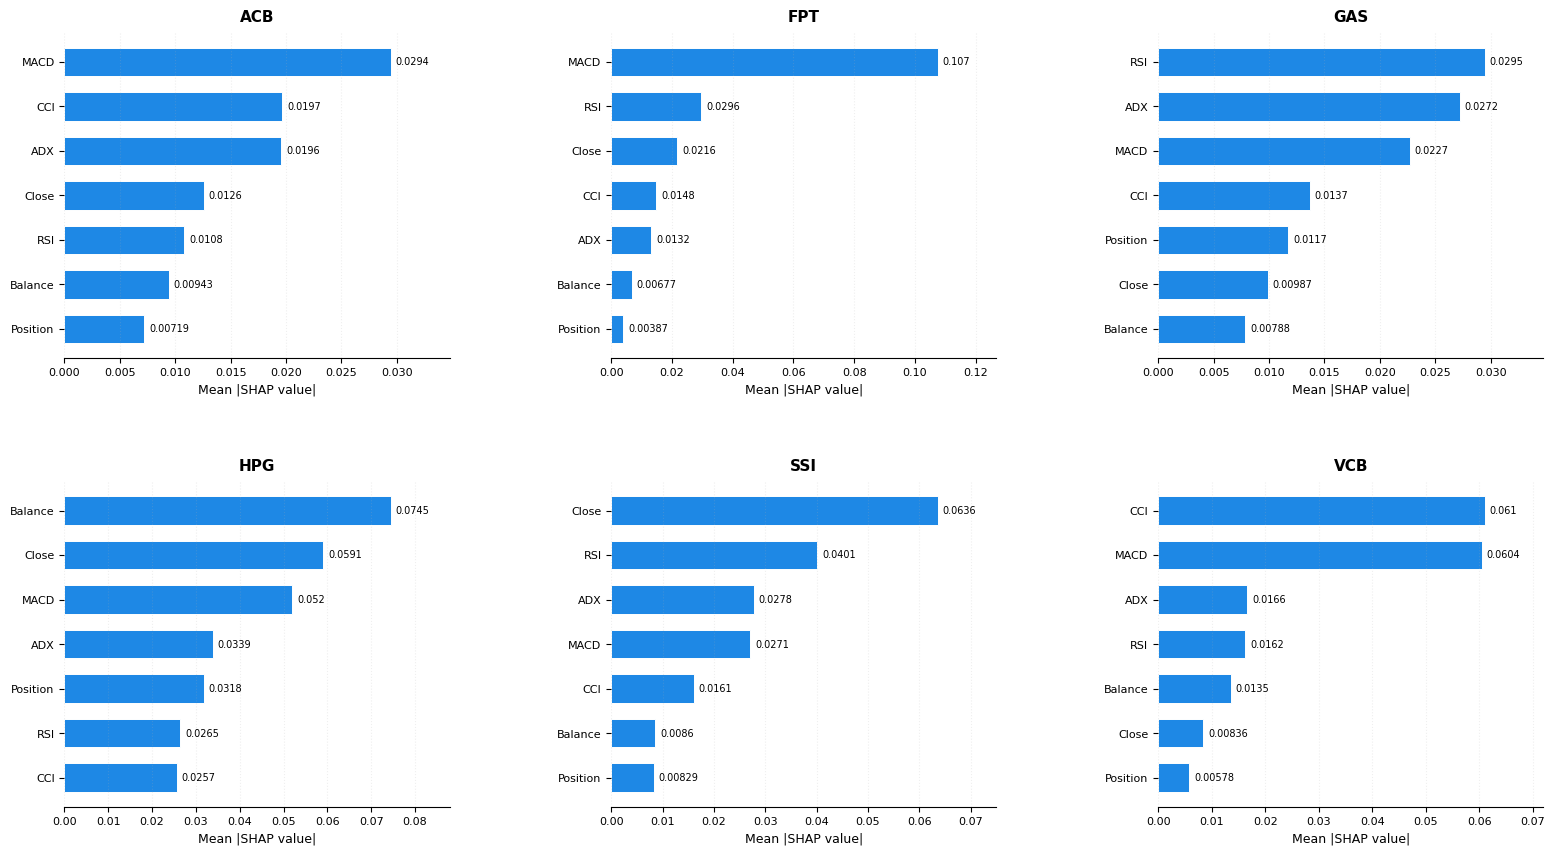

### BAD period — Waterfall plot

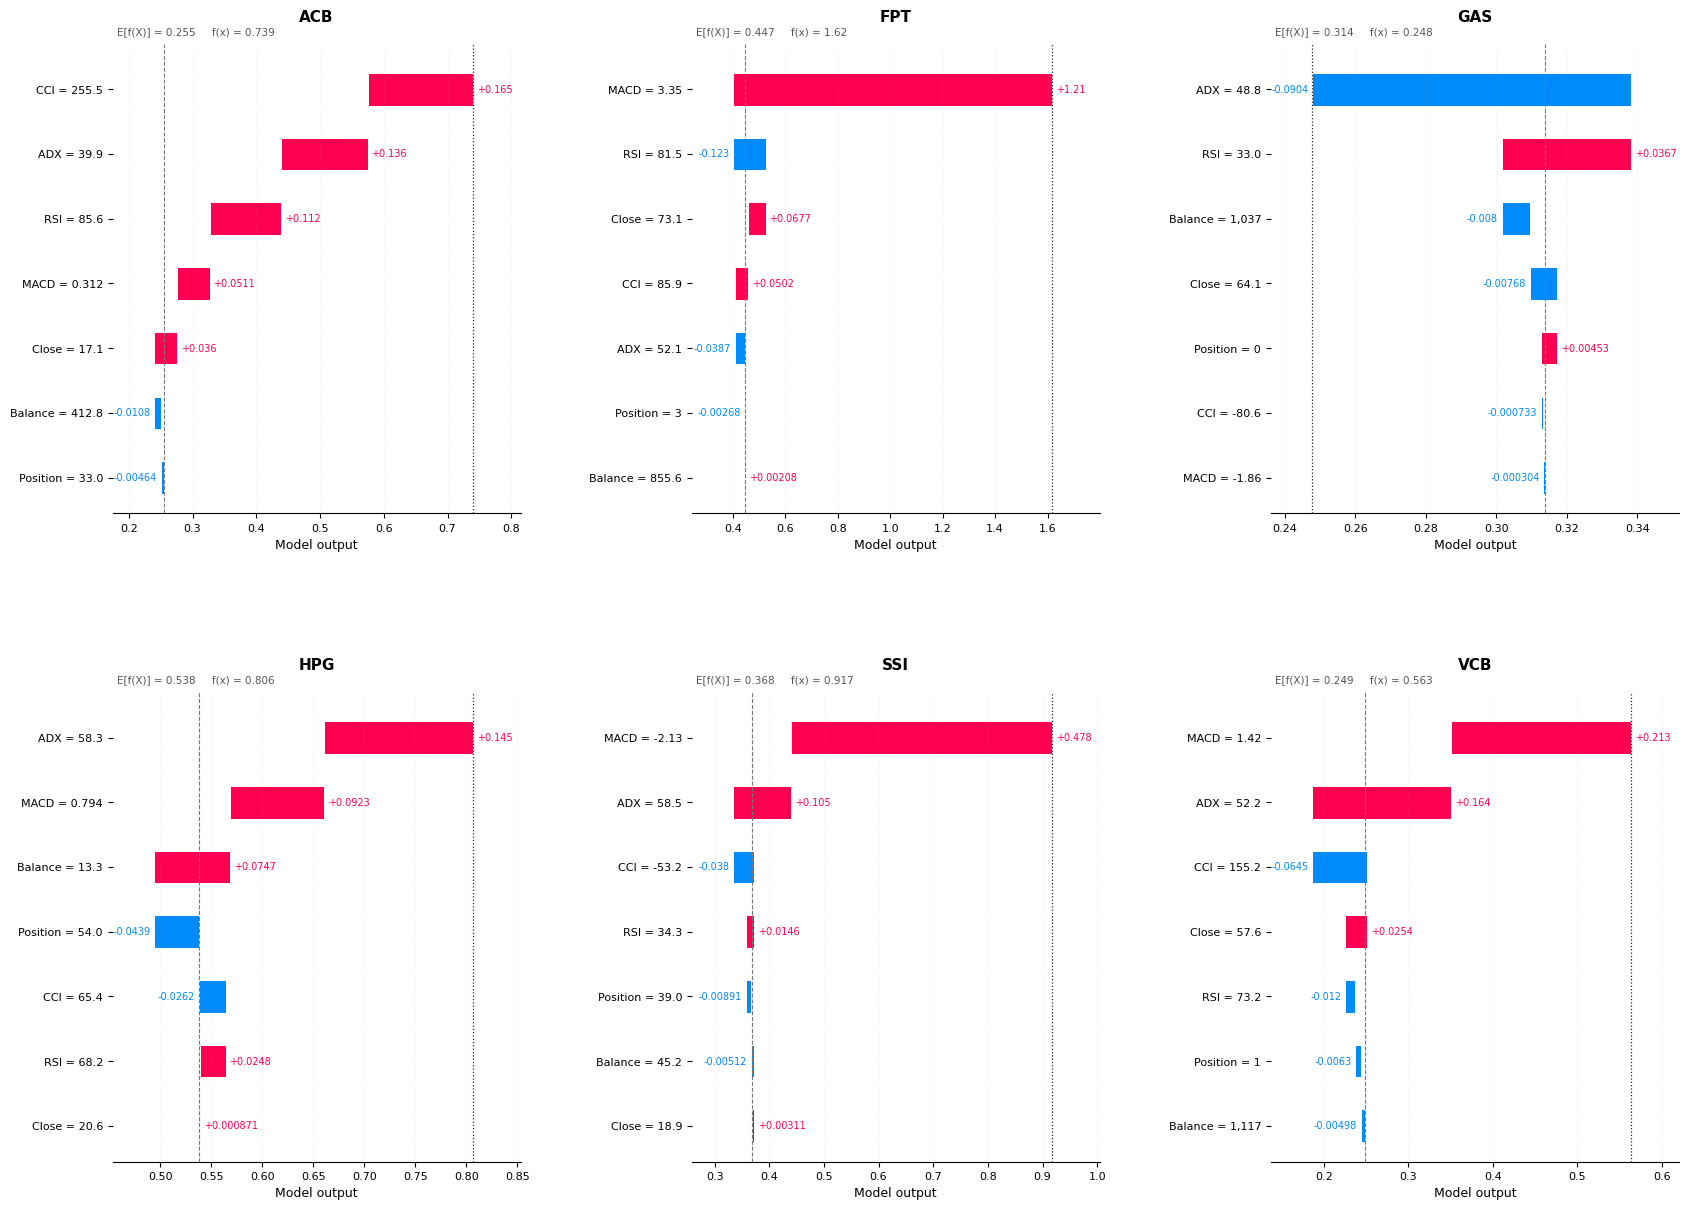

### BAD period — Beeswarm plot

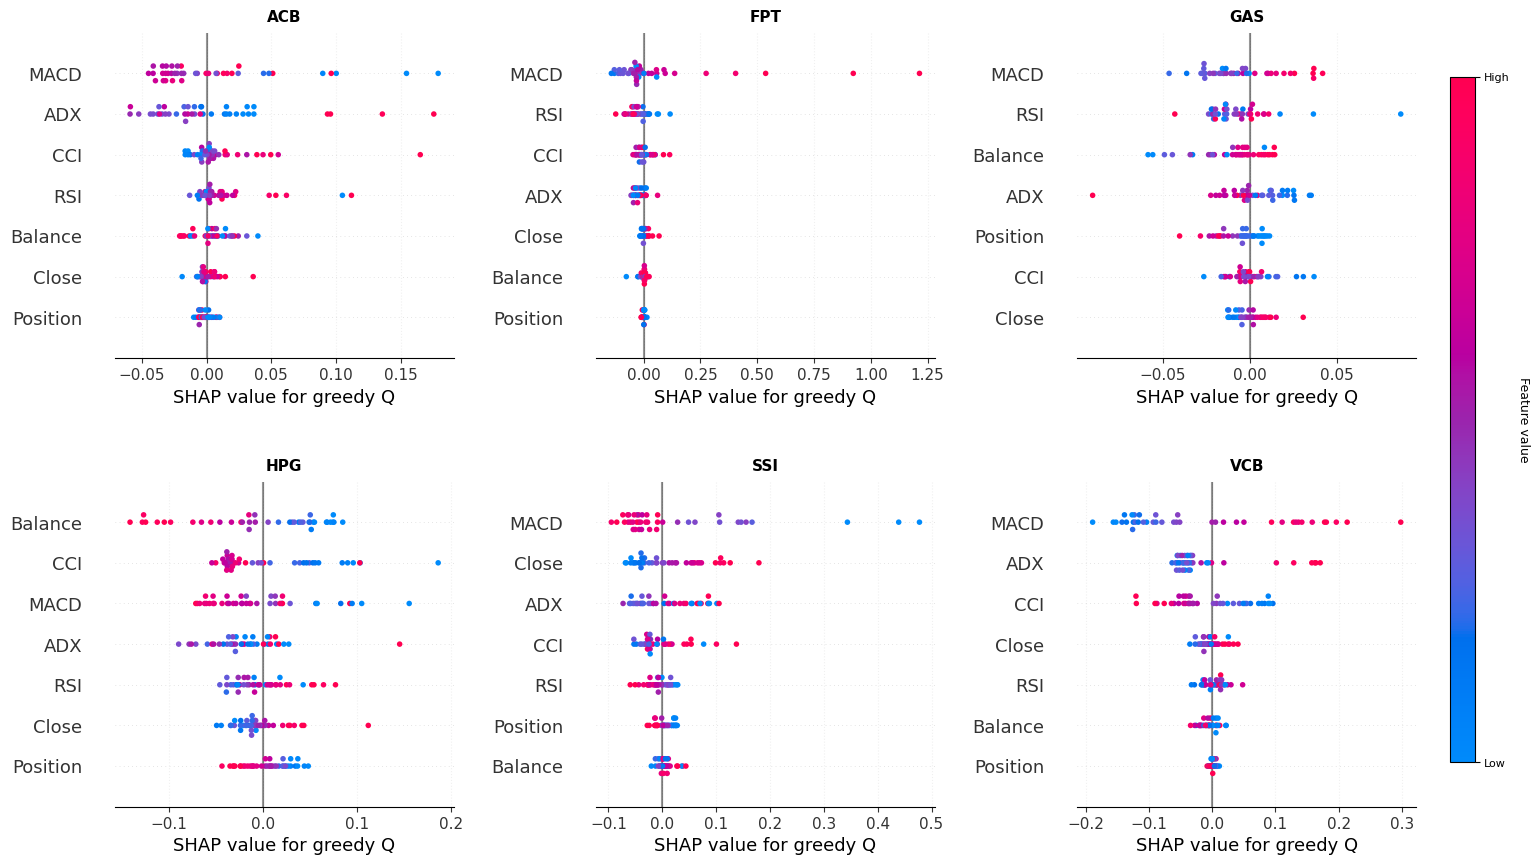

### BAD period — Summary plot

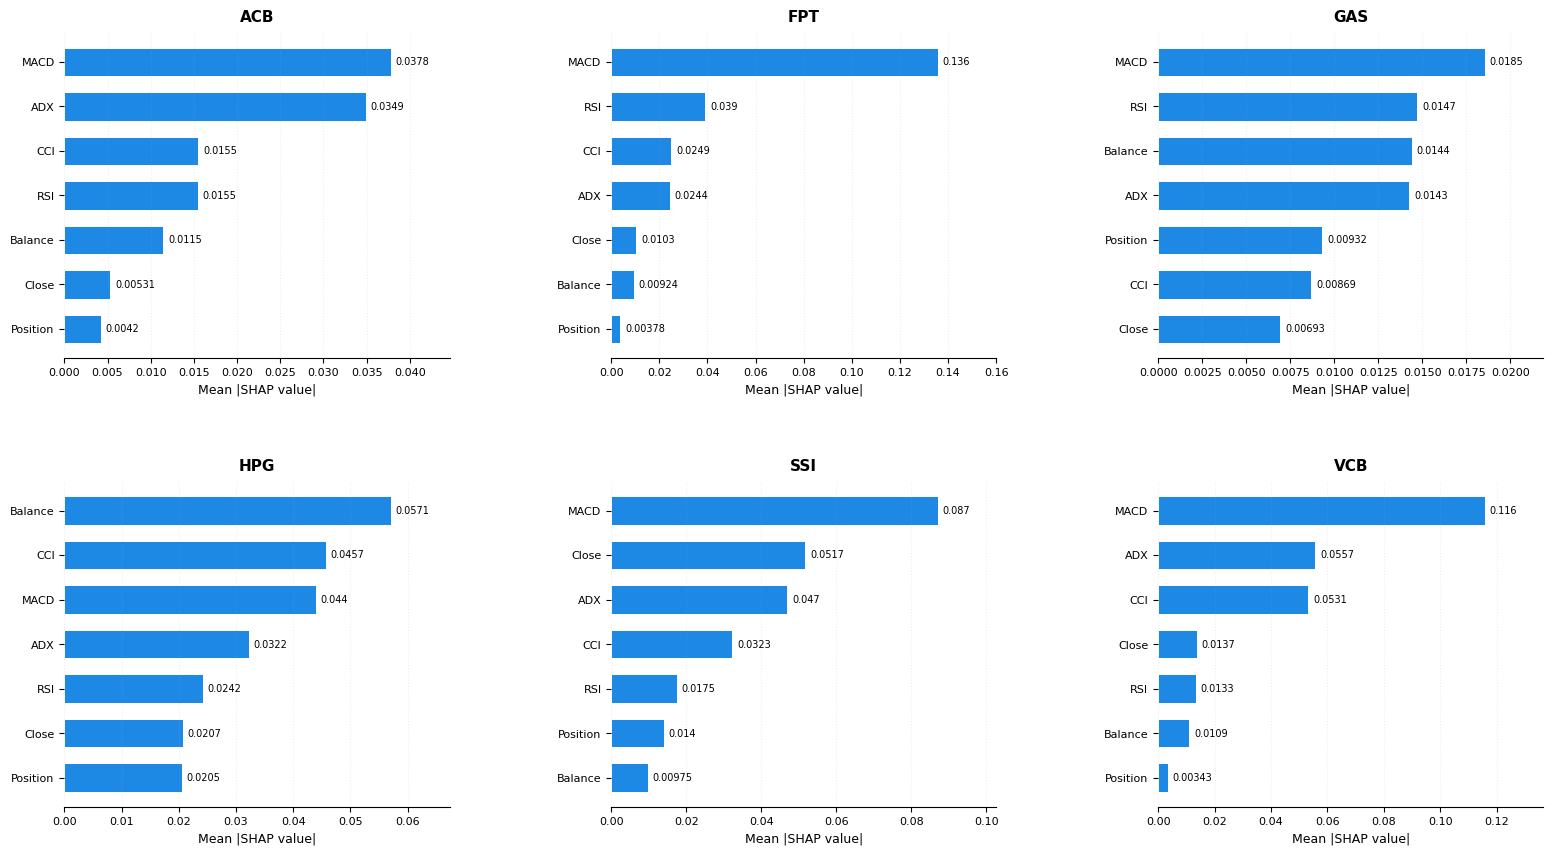

In [8]:
# Tổng hợp đủ 3 loại SHAP plot: mỗi hình chứa toàn bộ 6 checkpoint.
COMBINED_SHAP_STYLE = {
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
}
SHAP_POSITIVE_COLOR = '#ff0051'
SHAP_NEGATIVE_COLOR = '#008bfb'


def _format_feature_value(value):
    if abs(value) >= 1000:
        return f'{value:,.0f}'
    if abs(value) >= 10:
        return f'{value:.1f}'
    return f'{value:.3g}'


def _plot_waterfall_panel(ax, result, ticker):
    """Waterfall cục bộ cho trạng thái có tổng |SHAP| lớn nhất."""
    values = result['values']
    sample = result['sample']
    row_index = int(np.argmax(np.abs(values).sum(axis=1)))
    row_values = values[row_index]
    row_features = sample[row_index]
    order = np.argsort(np.abs(row_values))  # feature lớn nhất nằm trên cùng
    base_value = float(result['base_value'])
    prediction = base_value + float(row_values.sum())

    running_value = base_value
    left_edges, widths, colors = [], [], []
    for feature_index in order:
        next_value = running_value + float(row_values[feature_index])
        left_edges.append(min(running_value, next_value))
        widths.append(abs(next_value - running_value))
        colors.append(
            SHAP_POSITIVE_COLOR if row_values[feature_index] >= 0 else SHAP_NEGATIVE_COLOR
        )
        running_value = next_value

    # Giãn các hàng theo trục Y để nhãn feature và giá trị SHAP không đè nhau.
    y_positions = np.arange(len(order), dtype=float) * 1.35
    ax.barh(
        y_positions, widths, left=left_edges, height=0.68,
        color=colors, edgecolor='white', linewidth=0.7,
    )
    ax.set_yticks(
        y_positions,
        [
            f'{SHAP_FEATURES[index]} = {_format_feature_value(row_features[index])}'
            for index in order
        ],
    )
    data_min = min(left_edges)
    data_max = max(left + width for left, width in zip(left_edges, widths))
    x_span = max(data_max - data_min, 1e-9)
    for y_position, feature_index, left, width in zip(
        y_positions, order, left_edges, widths
    ):
        contribution = float(row_values[feature_index])
        endpoint = left + width if contribution >= 0 else left
        ax.text(
            endpoint + (0.012 * x_span if contribution >= 0 else -0.012 * x_span),
            y_position,
            f'{contribution:+.3g}',
            va='center',
            ha='left' if contribution >= 0 else 'right',
            fontsize=7,
            color=(SHAP_POSITIVE_COLOR if contribution >= 0 else SHAP_NEGATIVE_COLOR),
        )

    ax.axvline(base_value, color='#777777', linestyle='--', linewidth=0.8)
    ax.axvline(prediction, color='#222222', linestyle=':', linewidth=0.9)
    # Chừa khoảng hai bên để annotation không lấn sang nhãn trục Y.
    ax.set_xlim(data_min - 0.13 * x_span, data_max + 0.15 * x_span)
    ax.set_ylim(y_positions[0] - 0.75, y_positions[-1] + 0.95)
    ax.text(
        0.01, 1.02,
        f'E[f(X)] = {base_value:.3g}     f(x) = {prediction:.3g}',
        transform=ax.transAxes, fontsize=7.5, color='#555555',
    )
    ax.set_title(ticker, fontweight='bold', pad=16)
    ax.set_xlabel('Model output')
    ax.grid(axis='x', linestyle=':', alpha=0.18)
    ax.spines[['top', 'right', 'left']].set_visible(False)


def _plot_beeswarm_panel(ax, result, ticker):
    """Beeswarm chuẩn qua shap.summary_plot dạng dot."""
    plt.sca(ax)
    shap.summary_plot(
        result['values'],
        result['sample'],
        feature_names=list(SHAP_FEATURES),
        plot_type='dot',
        max_display=len(SHAP_FEATURES),
        color_bar=False,
        show=False,
        plot_size=None,
    )
    ax.set_title(ticker, fontweight='bold', pad=8)
    ax.set_xlabel('SHAP value for greedy Q')
    ax.axvline(0, color='#777777', linewidth=0.8, zorder=0)
    ax.grid(axis='x', linestyle=':', alpha=0.18)
    ax.spines[['top', 'right', 'left']].set_visible(False)


def _plot_summary_panel(ax, result, ticker):
    """Summary bar chuẩn: mean absolute SHAP trên các trạng thái mẫu."""
    importance = np.mean(np.abs(result['values']), axis=0)
    order = np.argsort(importance)
    y_positions = np.arange(len(order))
    bars = ax.barh(
        y_positions,
        importance[order],
        height=0.64,
        color='#1e88e5',
        edgecolor='white',
        linewidth=0.7,
    )
    ax.set_yticks(y_positions, [SHAP_FEATURES[index] for index in order])
    ax.set_title(ticker, fontweight='bold', pad=8)
    ax.set_xlabel('Mean |SHAP value|')
    ax.grid(axis='x', linestyle=':', alpha=0.20)
    ax.spines[['top', 'right', 'left']].set_visible(False)

    max_value = max(float(importance.max()), 1e-12)
    for bar, value in zip(bars, importance[order]):
        ax.text(
            value + max_value * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{value:.3g}',
            va='center',
            fontsize=7,
        )
    ax.set_xlim(right=max_value * 1.18)


def _finish_combined_figure(fig, axes, add_colorbar=False):
    fig.subplots_adjust(
        left=0.10,
        right=0.90 if add_colorbar else 0.97,
        top=0.94,
        bottom=0.08,
        wspace=0.42,
        hspace=0.38,
    )
    if add_colorbar:
        scalar = mpl.cm.ScalarMappable(
            norm=mpl.colors.Normalize(vmin=0, vmax=1),
            cmap=shap.plots.colors.red_blue,
        )
        scalar.set_array([])
        colorbar = fig.colorbar(
            scalar,
            ax=axes.ravel().tolist(),
            fraction=0.018,
            pad=0.025,
            aspect=28,
        )
        colorbar.set_ticks([0, 1], labels=['Low', 'High'])
        colorbar.set_label('Feature value', rotation=270, labelpad=14)
    plt.show()
    plt.close(fig)


def show_combined_shap_plots(period_results, period_label):
    """Xuất 3 hình tổng hợp; mỗi hình gồm 6 checkpoint theo bố cục 2 x 3."""
    with mpl.rc_context(COMBINED_SHAP_STYLE):
        display(Markdown(f'### {period_label} period — Waterfall plot'))
        fig, axes = plt.subplots(2, 3, figsize=(18, 13))
        for ax, ticker in zip(axes.flat, TICKERS):
            _plot_waterfall_panel(ax, period_results[ticker], ticker)
        _finish_combined_figure(fig, axes)

        display(Markdown(f'### {period_label} period — Beeswarm plot'))
        fig, axes = plt.subplots(2, 3, figsize=(17, 9))
        for ax, ticker in zip(axes.flat, TICKERS):
            _plot_beeswarm_panel(ax, period_results[ticker], ticker)
        _finish_combined_figure(fig, axes, add_colorbar=True)

        display(Markdown(f'### {period_label} period — Summary plot'))
        fig, axes = plt.subplots(2, 3, figsize=(17, 9))
        for ax, ticker in zip(axes.flat, TICKERS):
            _plot_summary_panel(ax, period_results[ticker], ticker)
        _finish_combined_figure(fig, axes)


show_combined_shap_plots(shap_good_results, 'GOOD')
show_combined_shap_plots(shap_bad_results, 'BAD')
